# Libraries import and Data Loading

In [18]:
# Core data manipulation and numerical computation libraries.
# pandas provides tabular data structures and operations,
# while numpy supports efficient numerical computations.
import pandas as pd
import numpy as np

# Visualization libraries used for exploratory data analysis
# and model evaluation diagnostics.
import seaborn as sns
import matplotlib.pyplot as plt

# Tools for dataset splitting and cross-validation.
# Stratified sampling is essential due to class imbalance
# in the attrition target variable.
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Preprocessing utilities.
# - ColumnTransformer allows different preprocessing pipelines
#   for numeric and categorical features.
# - Pipeline ensure that preprocessing and modeling steps
#   are applied consistently and without data leakage.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Imputation strategies for handling missing values.
# Median imputation is used for numeric features due to skewness,
# while most-frequent imputation is used for categorical variables.
from sklearn.impute import SimpleImputer

# Classification models.
# Logistic Regression is used as an interpretable baseline model,
# while tree-based ensemble methods are used to capture non-linear
# relationships and interaction effects.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier

# Evaluation metrics and diagnostic visualizations.
# These are used to assess both discriminative performance
# (e.g. ROC AUC) and error structure (e.g. confusion matrix),
# which is critical in asymmetric problems such as employee attrition.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import shap

In [19]:
# Load the employee attrition dataset
attr = pd.read_csv("/kaggle/input/employeeattrition1/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# For xlsx files, comment the previous line of code with # and uncomment the last line of code,
# pasting the correct dataset path

#attr = pd.read_excel("/kaggle/dataset/path.xlsx")


# Data Exploration

In [20]:
# dataset variable name + . + head -the top rows- + (number of rows selected, in this case 0-99)
attr.head(100)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,54,No,Travel_Rarely,1217,Research & Development,2,4,Technical Degree,1,126,...,1,80,1,16,5,1,4,3,0,3
96,24,No,Travel_Rarely,1353,Sales,3,2,Other,1,128,...,1,80,1,4,2,2,3,2,0,2
97,28,No,Non-Travel,120,Sales,4,3,Medical,1,129,...,2,80,0,5,3,4,5,4,0,4
98,58,No,Travel_Rarely,682,Sales,10,4,Medical,1,131,...,3,80,0,38,1,2,37,10,1,8


In [21]:
attr.shape
attr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [22]:
attr["Attrition"].value_counts(normalize=True)


Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

The following plot helps to visualise the distribution of the target variable (Attrition).
This plot is used to assess class balance and to determine whether the classification problem is imbalanced.

Understanding the target distribution at this stage is critical,
as it directly informs the choice of evaluation metrics and the
potential need for imbalance-aware modeling strategies later on.

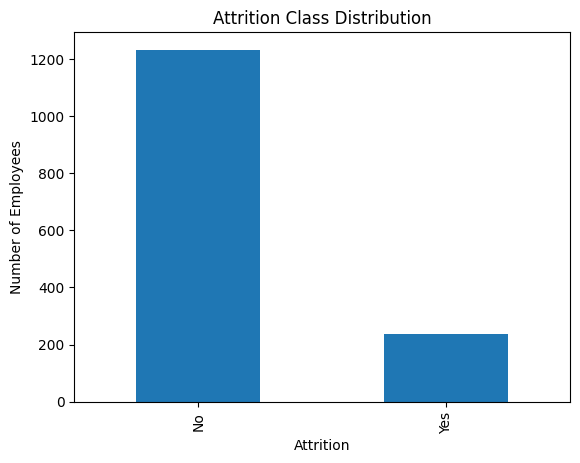

In [23]:
attr["Attrition"].value_counts().plot(
    kind="bar",
    title="Attrition Class Distribution"
)
plt.ylabel("Number of Employees")
plt.show()


In [24]:
# Checking for missing values, none found.

attr.isna().sum().sort_values(ascending=False)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

The next plot is created to give insights on the marginal distributions of all numeric features.
This step helps to identify skewness and heavy-tailed distributions, to detect potential outliers, to distinguish between continuous, count-based, and ordinal variables, which help to understand if later preprocessing is needed or not (eg, scaling/imputation).
Here a fixed number of bins is picked (30) to provide a sufficient resolution for the shape assessment, without introducing excessive "visual noise"

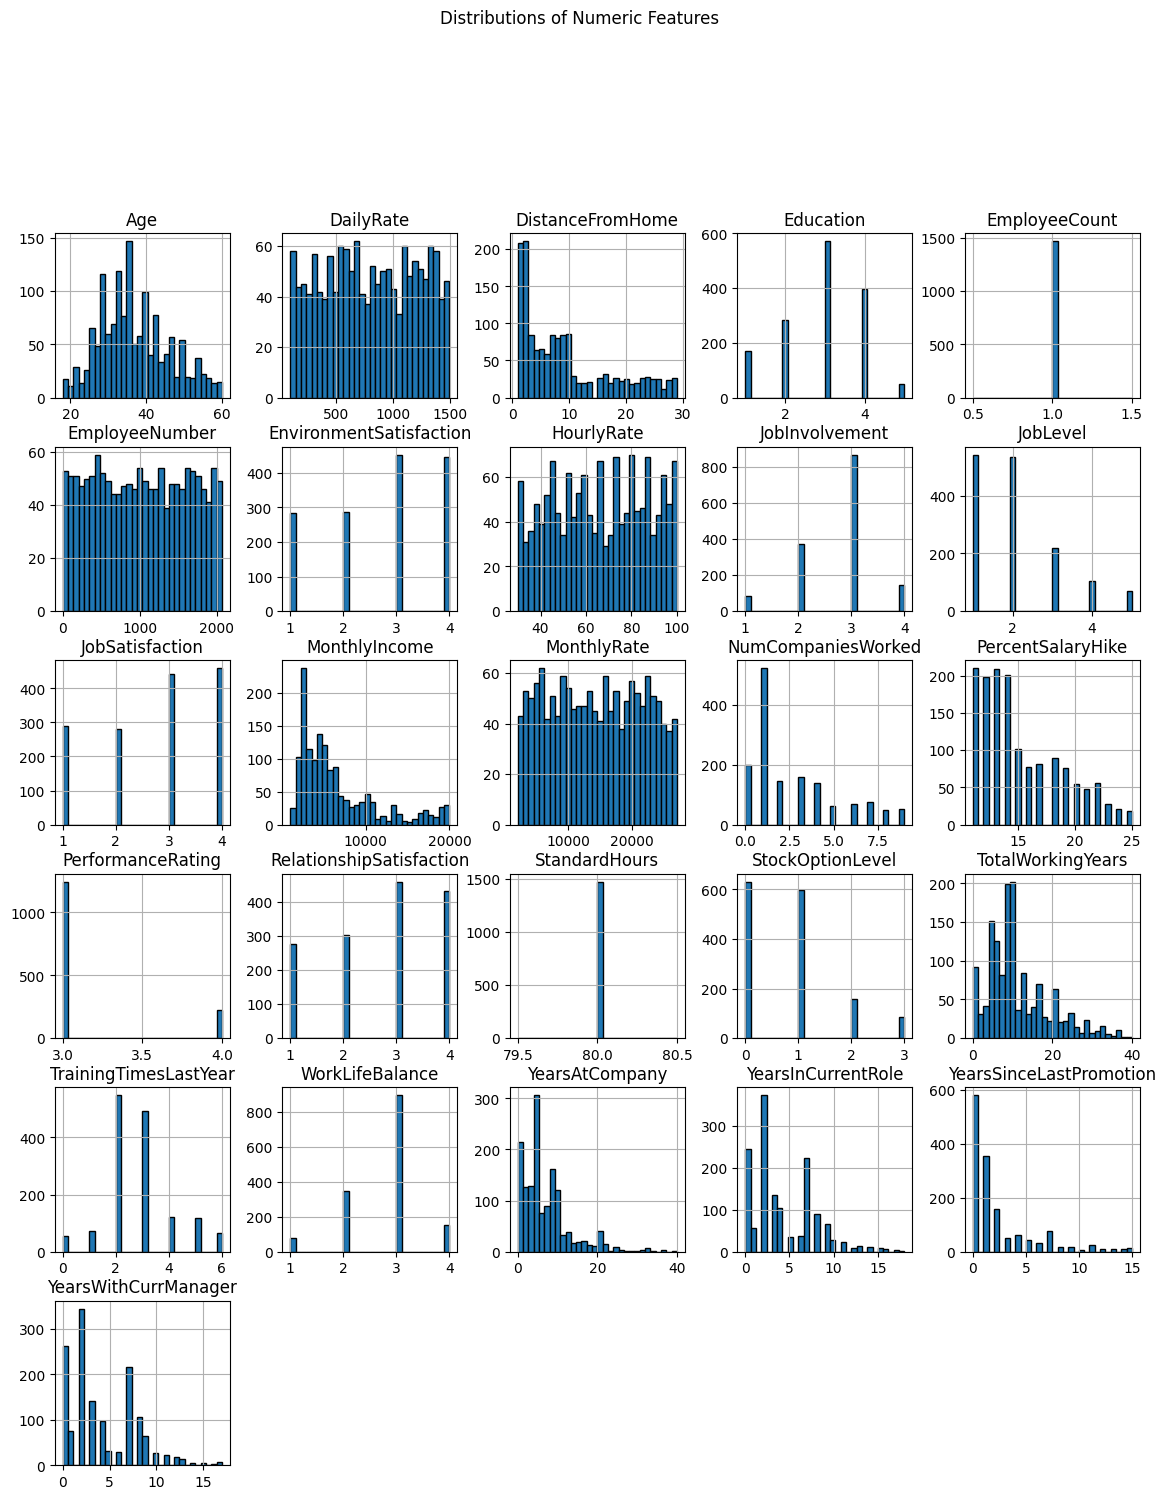

In [25]:
numeric_cols = attr.select_dtypes(include="number").columns

attr[numeric_cols].hist(
    figsize=(14, 16),
    bins=30,
    edgecolor="black"
)
plt.suptitle("Distributions of Numeric Features", y=1.02)
plt.show()


In [26]:
# Here we are identifying categorical features in the dataset (nominal or ordinal attributes)
# that require different treatment from numerical features. Additionally, the target variable is
# excluded from the set of explanatory features, as it is handled separately because it serves as the
# outcome variable rather than an input to be explored as a predictor at this stage.
categorical_cols = attr.select_dtypes(include="object").columns
categorical_cols = categorical_cols.drop("Attrition")


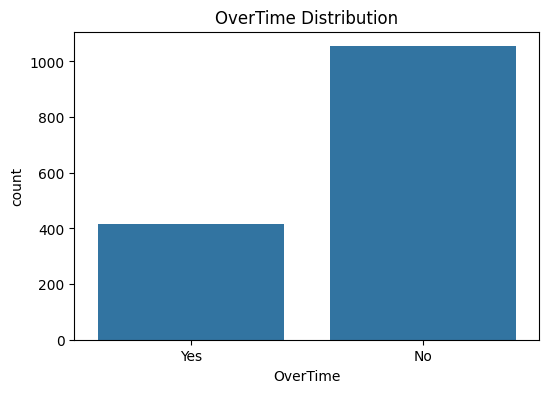

In [27]:
# Plotting OverTime distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=attr, x="OverTime")
plt.title("OverTime Distribution")
plt.show()


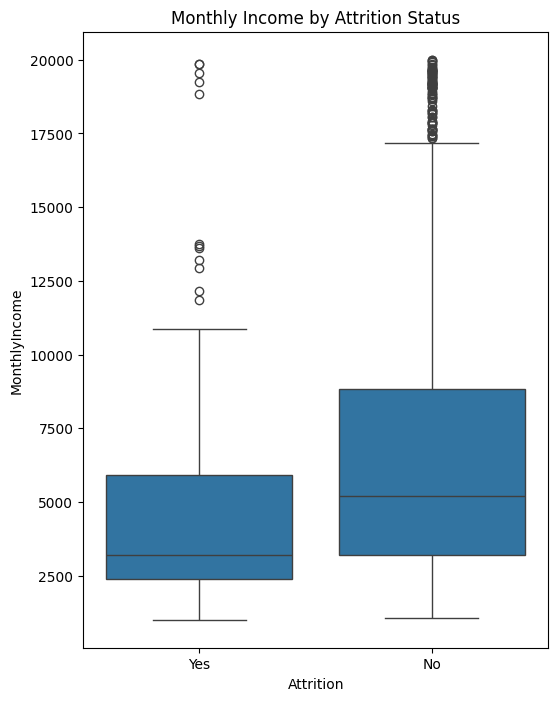

In [28]:
#Plotting MonthlyIncome by Attrition status (Y/N)
plt.figure(figsize=(6, 8))
sns.boxplot(
    data=attr,
    x="Attrition",
    y="MonthlyIncome"
)
plt.title("Monthly Income by Attrition Status")
plt.show()


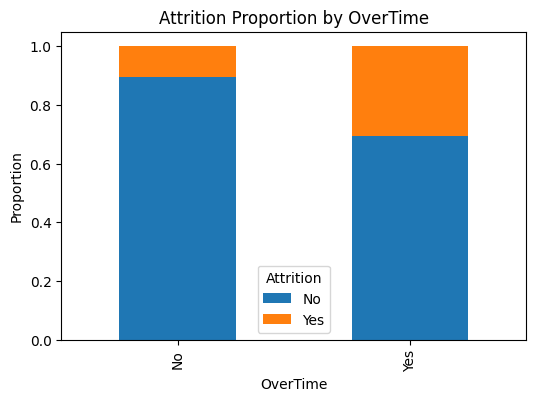

In [29]:
# Plotting Attrition Proportion by OverTime
# Normalising by row (index) removes the effect of different group sizes
# and allows direct comparison of attrition risk between employees who
# work overtime and those who do not.
pd.crosstab(
    attr["OverTime"],
    attr["Attrition"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4)
)

plt.title("Attrition Proportion by OverTime")
plt.ylabel("Proportion")
plt.show()


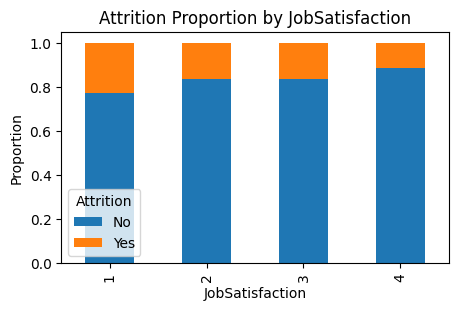

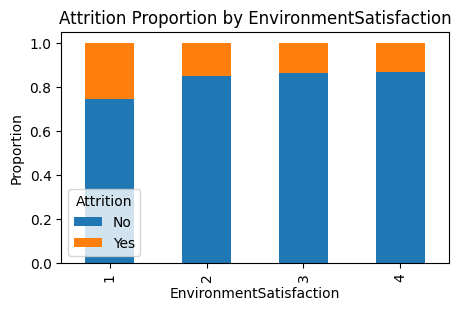

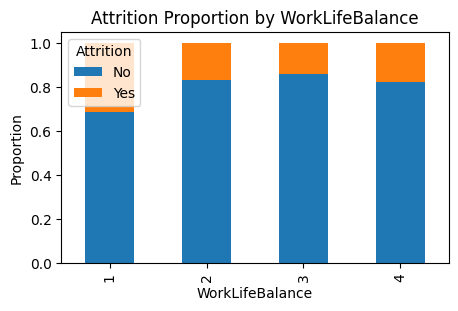

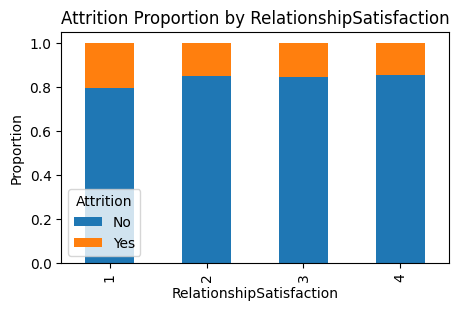

In [30]:
# Here the rlationship between ordinal satisfaction-related variables and attrition
# are examined, since they capture psychosocial aspect of the job.
# such variables are analysed using proportion plots to avoid assumptions of
# linearity or equal spacing between satisfaction levels

satisfaction_vars = [
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "RelationshipSatisfaction"
]

for var in satisfaction_vars:
    pd.crosstab(
        attr[var],
        attr["Attrition"],
        normalize="index"
    ).plot(
        kind="bar",
        stacked=True,
        figsize=(5, 3),
        title=f"Attrition Proportion by {var}"
    )
    plt.ylabel("Proportion")
    plt.show()


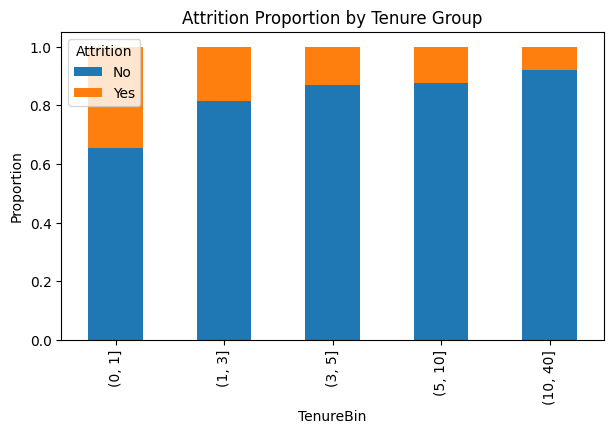

In [31]:
# the following plot categorises the tenure (YearsAtCompany) into intervals.
# Binning helps to capture non-linear relationships between tenure and attrition that may not
# appear in correlations or summary statistics.
# The chosen intervals reflecting meaningful career stages are:
# - 0–1 years: early tenure / onboarding phase
# - 1–3 years: initial adjustment period
# - 3–5 years: medium-term tenure
# - 5–10 years: established employees
# - >10 years: long-tenured employees

attr["TenureBin"] = pd.cut(
    attr["YearsAtCompany"],
    bins=[0, 1, 3, 5, 10, 40]
)

pd.crosstab(
    attr["TenureBin"],
    attr["Attrition"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4)
)

plt.title("Attrition Proportion by Tenure Group")
plt.ylabel("Proportion")
plt.show()


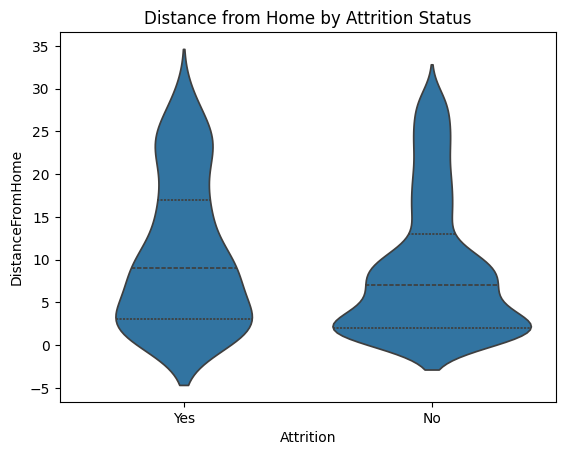

In [32]:
# here there is the comparison of the distribution of commuting distance between employees
# who leave and those who stay. The following violin plot is used to visualize the full distribution and potential
# asymmetry, rather than relying solely on central tendency measures such as mean/median
sns.violinplot(
    data=attr,
    x="Attrition",
    y="DistanceFromHome",
    inner="quartile"
)
plt.title("Distance from Home by Attrition Status")
plt.show()


To note: the violin plot shows a clear difference in distribution shape of commuting distance between employees who leave and those who stay.
Employees who stay are more tightly concentrated at short commuting distances, with a strong density near the lower end of the scale.
Employees who leave show a broader distribution, with a slightly hiher median distance, a wider interquartile range, and a noticeable heavier upper tail, indicating a greater presence of long commutes.
Importantly, there is a substantial overlap between the two distributions.
These patterns suggest that the commuting distancce acts more as a contextual risk factor, rather than a dominant driver of attrition.

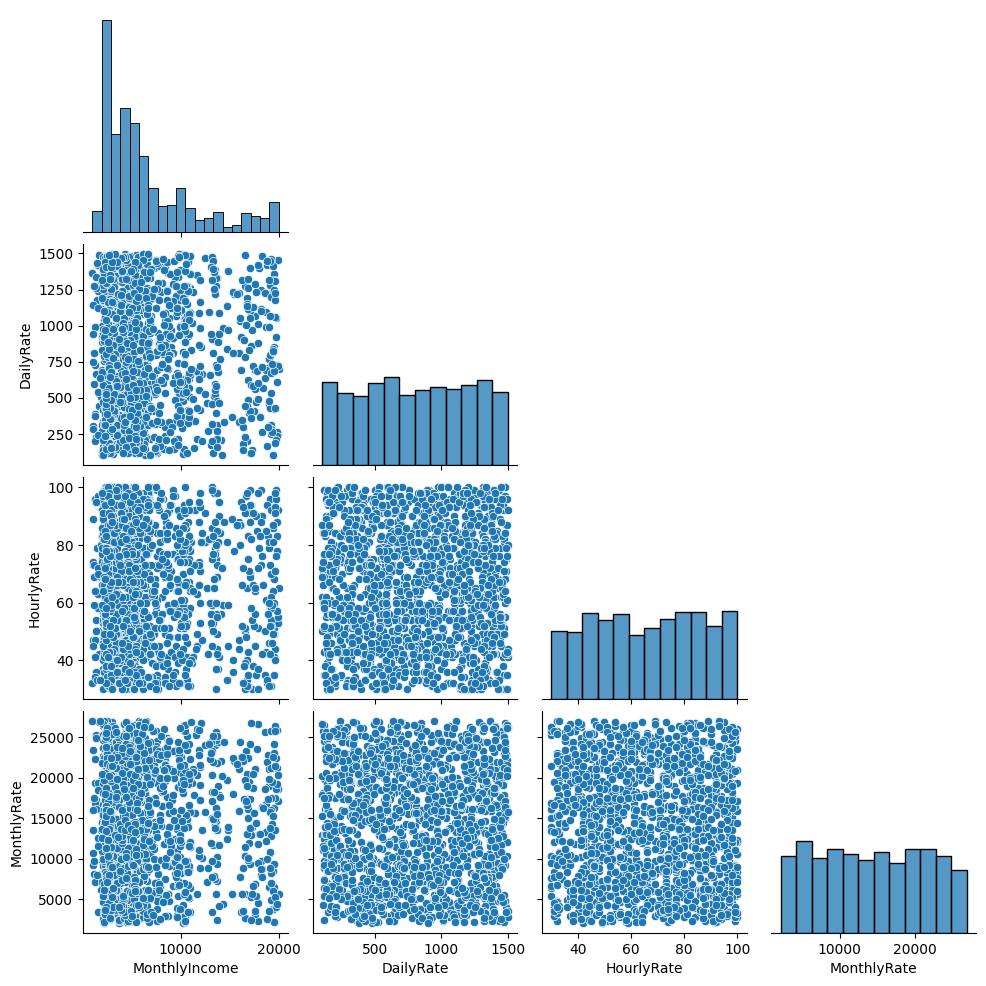

In [33]:
# the following analysis of the income-related variables is conducted to assess the redundancy between
# the different salary representations.
income_cols = ["MonthlyIncome", "DailyRate", "HourlyRate", "MonthlyRate"]
sns.pairplot(attr[income_cols], corner=True)
plt.show()


Two key patterns: 

Strong linear structure involving MonthlyIncome - Scatterplots between MonthlyIncome and the rate-based variables form elongated, structured clouds rather than diffuse patterns.
This indicates that the rate variables are largely determined by the same underlying salary information encoded in MonthlyIncome.

Limited independent structure among rate variables - Relationships between DailyRate, HourlyRate, and MonthlyRate appear dense but uninformative, with no clear additional behavioural signal.
Histograms on the diagonal show broad but relatively uniform distributions, consistent with administrative or payroll-derived quantities rather than behavioural variables.

Overall, the plot suggests that these variables are not independent sources of information, but alternative encodings of the same compensation construct. (ChatGPT)


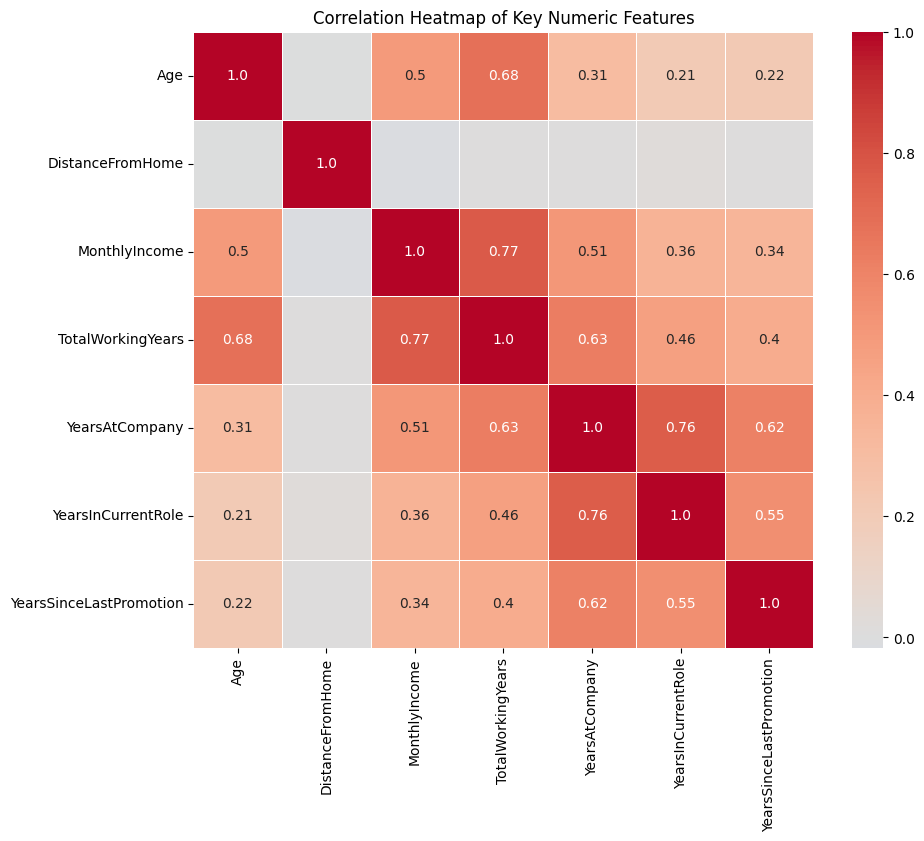

In [34]:
# A subset of numeric variables is selected for correlation analysis.
# These variables represent demographic characteristics, compensation,
# and different aspects of tenure, and are examined together to assess
# structural relationships and potential multicollinearity prior to modeling.

numeric_cols = [
    "Age", "DistanceFromHome", "MonthlyIncome",
    "TotalWorkingYears", "YearsAtCompany",
    "YearsInCurrentRole", "YearsSinceLastPromotion"
]


# the following line computes pairwise Pearson correlation matrix.
# Correlation analysis at this stage is exploratory and is used to
# identify strong linear associations that may affect model stability
# and interpretability, particularly for linear models.
corr = attr[numeric_cols].corr()

annot = corr.round(2).astype(str)
annot[np.abs(corr) < 0.2] = ""

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=annot,
    fmt=""
)
plt.title("Correlation Heatmap of Key Numeric Features")
plt.show()


# Data Preparation & Preprocessing

In [35]:
TARGET = "Attrition"

# Separating target variable y from the feature matrix X
y = attr[TARGET]
X = attr.drop(columns = [TARGET])


In [36]:
print(attr["Over18"].nunique())
print(attr["EmployeeCount"].nunique())
print(attr["StandardHours"].nunique())

1
1
1


Several variables are removed prior to modelling based on structural, statistical, and semantic considerations identified during exploratory analysis. EmployeeNumber is a unique identifier that distinguishes observations but carries no behavioural or organisational meaning; retaining it could introduce spurious patterns without explanatory value. EmployeeCount and StandardHours are constant across all employees and therefore contain no information capable of explaining variation in attrition. Similarly, Over18 takes a single value for all observations and provides no discriminatory signal despite its categorical form.

In addition, payroll rate variables (DailyRate, HourlyRate, and MonthlyRate) are excluded. Exploratory analysis shows that these features are strongly redundant with MonthlyIncome, as they represent alternative encodings of the same underlying compensation construct. Retaining all such variables would introduce multicollinearity, inflate the apparent importance of compensation-related factors, and reduce interpretability, particularly for linear models. Consequently, MonthlyIncome is retained as the canonical compensation measure, while a psychologically meaningful transformation capturing relative pay effects (IncomePerLevel) is introduced at a later stage.

In [37]:
cols_drop = ["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18", "HourlyRate", "DailyRate", "MonthlyRate"]

X = X.drop(columns = cols_drop)

In [38]:
#Explicit target encoding (categorical to numerical)
y = y.map({"Yes": 1, "No": 0})


In [39]:
y.value_counts(normalize=True)


Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

The attrition outcome exhibits moderate class imbalance, with approximately 83.9% of employees remaining and 16.1% leaving. While this imbalance is non-negligible, corrective techniques such as resampling are not applied a priori. Blindly rebalancing the dataset can distort real-world class proportions, inflate false positive rates, and lead to misleading performance assessments, particularly in applied settings where predicted probabilities are used for decision support.

Employee attrition is inherently an asymmetric problem: failing to identify employees at risk of leaving (false negatives) typically carries a higher organisational cost than incorrectly flagging employees who ultimately stay (false positives). For this reason, initial model evaluation is conducted on the original data distribution using metrics that are robust to class imbalance and aligned with the problem context, including recall for the attrition class, F1-score, and ROC-AUC.

Before modifying the data distribution, class imbalance is instead addressed at the modeling level by incorporating class weights where supported. This approach allows the learning algorithm to penalise misclassification of the minority class more heavily, without altering the underlying data-generating process. In weighted classification, the model effectively optimises a cost-sensitive objective, prioritising the correct identification of attrition cases while preserving probabilistic interpretability.

The overall strategy therefore follows a staged approach: first diagnosing class imbalance, then training baseline models on the original data, and only introducing additional imbalance-handling techniques if empirical evaluation indicates that minority-class performance is inadequate.

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


The dataset is partitioned into training and validation subsets using an 80/20 split. The feature matrix 
𝑋
contains employee-level explanatory variables, while the target vector 
𝑦
encodes the attrition outcome, with values indicating whether an employee remains or leaves. Each observation in the feature matrix remains paired with its corresponding outcome throughout the split, ensuring that no label–feature mismatches are introduced.

Stratified sampling (stratify = y) is employed with respect to the attrition outcome to preserve the original class distribution in both the training and validation sets. Given the moderate class imbalance present in the data, an unstratified random split could result in substantially different attrition proportions across subsets, leading to unreliable evaluation and biased performance estimates. Stratification ensures that both subsets reflect the overall prevalence of attrition, thereby supporting fair and consistent model assessment.

A fixed random seed is used to control the stochasticity of the splitting process. This guarantees reproducibility across runs and enables meaningful comparison between models trained under identical data partitions. Such reproducibility is essential for debugging, methodological transparency, and scientific rigor.

In [41]:
# Final feature type definition

numeric_features = [
    "Age", "DistanceFromHome", "Education",
    "EnvironmentSatisfaction", "JobInvolvement",
    "JobLevel", "JobSatisfaction", "MonthlyIncome", "NumCompaniesWorked", "PercentSalaryHike",
    "PerformanceRating", "RelationshipSatisfaction",
    "StockOptionLevel", "TotalWorkingYears",
    "TrainingTimesLastYear", "WorkLifeBalance",
    "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager"
]

categorical_features = [
    "BusinessTravel", "Department", "EducationField",
    "Gender", "JobRole", "MaritalStatus", "OverTime"
]

After feature selection and data cleaning, a second correlation analysis is conducted on the numeric features retained for modeling. While an earlier correlation matrix was used during exploratory analysis to understand raw relationships among selected variables, this step serves a distinct diagnostic purpose: to verify the structural properties of the final feature set that will be provided to the learning algorithms.

Specifically, this analysis is used to confirm that preprocessing decisions—such as feature removal, consolidation of redundant variables, and feature engineering—have not introduced unintended linear dependencies or excessive multicollinearity among the remaining numeric features. This is particularly relevant for linear models, where correlated inputs can lead to unstable coefficient estimates and reduced interpretability.

Only correlations with an absolute magnitude of at least 0.2 are annotated in the heatmap in order to emphasise relationships that are likely to be practically meaningful, while avoiding visual clutter from weak associations. The resulting plot therefore functions as a sanity check on the cleaned feature space, rather than as an exploratory tool for discovery.

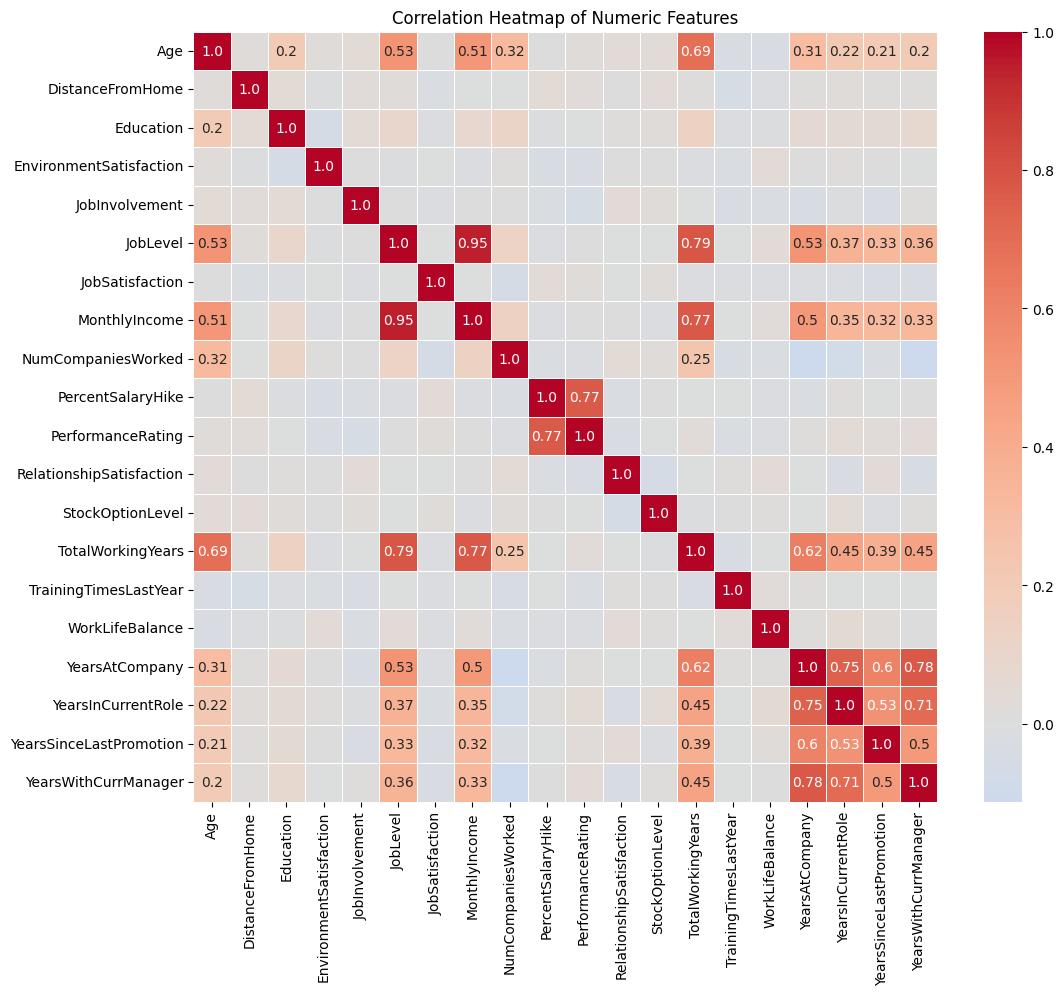

In [42]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

corr = X_train[numeric_features].corr()

# Create annotation matrix:
# show value only if absolute correlation >= 0.2
annot = corr.round(2).astype(str)
annot[np.abs(corr) < 0.2] = ""

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=annot,
    fmt=""
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [43]:
#Feature Engineering (inside the pipeline, safe-zone)
# FE is added before modeling but after split: this order matters because:
# FE must not use information from the validation set to influence training;
# In this case, the transformation uses only row-local information;
# No statistics are computed across rows;
# No target information is involved

# Even if this feature is engineered before the split, it would not technically leak, but placing it after the split is the best practice because
# it enforces discipline, it prevents bad habits when future features do require aggregation, and it keeps the mental model consistent: training
# and evaluation are independent worlds

# IncomePerLevel is chosen because the relative pay matters more than the absolute pay, plus it encodes dissatisfaction signal
# (E.G.: two employees can earn the same income and be in very different psychological states)
# FE is done manually because: the domain features rarely belong inside sklearn primitives, and explicit logic matters more than magic automation

X_train = X_train.copy()
X_val = X_val.copy()

X_train["IncomePerLevel"] = (
    X_train["MonthlyIncome"] / X_train["JobLevel"]
)

X_val["IncomePerLevel"] = (
    X_val["MonthlyIncome"] / X_val["JobLevel"]
)

numeric_features.append("IncomePerLevel")







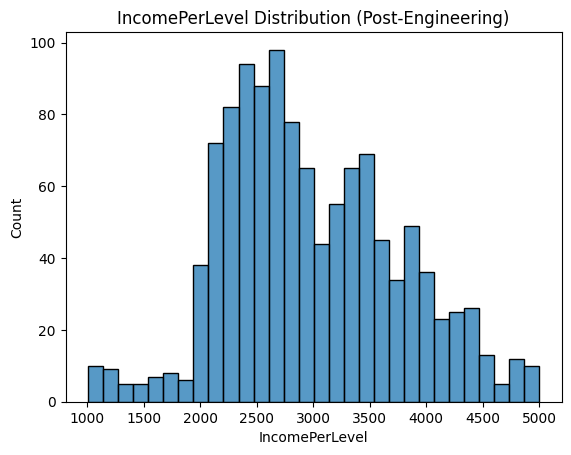

In [44]:
sns.histplot(X_train["IncomePerLevel"], bins=30)
plt.title("IncomePerLevel Distribution (Post-Engineering)")
plt.show()


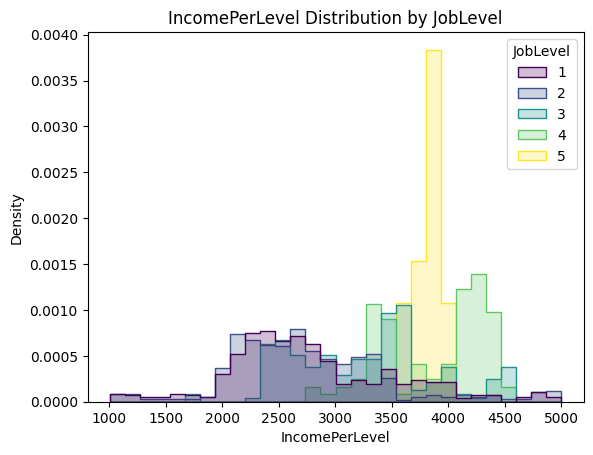

In [45]:
# Visualising how relative income (IncomePerLevel) is distributed across job levels.
# Overlaying the distributions allows comparison of within-level variability
# while keeping each job level on its own scale.

sns.histplot(
    data=X_train,
    x="IncomePerLevel",
    hue="JobLevel",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    palette = "viridis"
)
plt.title("IncomePerLevel Distribution by JobLevel")
plt.show()


In [46]:
#Missing values strategy (numeric pipeline, there are no missing values but it is still a good practice to follow)
#Median is chosen because it is robust to skewed distributions and extreme values, which are common in salary and tenue
# variables.
#scaling is required for logistic regression
# TWO preprocessing pipelines are defined because different models
# have different requirements:
# - Linear models (e.g. logistic regression) benefit from feature scaling,
#   as they rely on distances and coefficient magnitudes.
# - Tree-based models do not require scaling and can perform better when
#   numeric values are kept in their original scale.
# Defining separate pipelines allows the same cleaned data to be used
# appropriately across different model families without data leakage.

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])



In [47]:
# Missing values strategy for categorical features
# Missing categories are treated as "unknown" rather than as random noise,
# so the most frequent category is used as a simple and stable imputation.
#
# One-hot encoding is applied to convert categorical values into numeric form.
# Dropping the first category avoids perfect multicollinearity in linear models.
# Ignoring unseen categories ensures that the model can safely handle
# new or rare values at prediction time without errors.

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])



In [48]:
#ColumnTransformer, the spine of clean machine learning
#powerful tool that prevents data leakage, guarantees reproducibility, and makes preprocessing model-agnostic

# Tree-based models use an unscaled numeric pipeline because
# they rely on feature ordering and threshold splits rather
# than distance or gradient magnitude.

# Using separate preprocessors preserves methodological
# correctness without duplicating feature logic.

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_unscaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)



In [49]:

# Sanity check after preprocessing
X_train_processed = preprocessor_scaled.fit_transform(X_train)

pd.DataFrame(X_train_processed).describe()


,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
count,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,...,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,-4.229421e-17,-4.682573e-17,8.760944e-17,1.510508e-17,2.537653e-16,7.703588e-17,1.601138e-16,-7.930164e-17,-5.739929e-17,-1.480297e-16,...,0.182823,0.070578,0.096088,0.053571,0.187075,0.232143,0.051020,0.459184,0.317177,0.289116
std,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,...,0.386686,0.256228,0.294838,0.225266,0.390137,0.422379,0.220133,0.498543,0.465575,0.453545
min,-2.070831e+00,-1.022219e+00,-1.855332e+00,-1.577622e+00,-2.469873e+00,-9.862649e-01,-1.548758e+00,-1.189876e+00,-1.083704e+00,-1.152896e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.628207e-01,-8.999145e-01,-8.821517e-01,-6.587098e-01,-1.048155e+00,-9.862649e-01,-6.479968e-01,-7.730452e-01,-6.812931e-01,-8.809738e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.088155e-01,-2.883928e-01,9.102879e-02,2.602021e-01,3.735637e-01,-7.011362e-02,2.527647e-01,-3.309550e-01,-2.788819e-01,-3.371285e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.541906e-01,5.677376e-01,1.064209e+00,1.179114e+00,3.735637e-01,8.460377e-01,1.153526e+00,4.033900e-01,5.259405e-01,7.505619e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,2.507205e+00,2.402303e+00,2.037390e+00,1.179114e+00,1.795282e+00,2.678340e+00,1.153526e+00,2.886856e+00,2.537997e+00,2.654020e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Modeling

Model with class imbalance handling

Experiment 1 - Linear Model 

The following experiment uses Logistic Regression as a transparent baseline model. The goal is to test the assumption that attrition can be approximated as a linear and additive process, where each feature contributes independently to the likelyhood of an employee leaving.
Logistic Regression's coefficients are directly interpretable, allowing both the direction and relative strenght of association to be examined.

The class weighting is applied to account for the moderate class imbalance, instructing the model to penalise missclassification of attrition cases more heavily without altering the original data distribution

              precision    recall  f1-score   support

           0       0.94      0.80      0.86       247
           1       0.41      0.72      0.52        47

    accuracy                           0.79       294
   macro avg       0.67      0.76      0.69       294
weighted avg       0.85      0.79      0.81       294

ROC AUC: 0.8182444655009045
[[198  49]
 [ 13  34]]


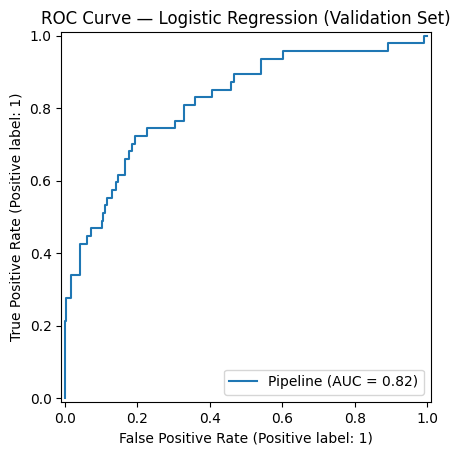

In [50]:
# here we define a logistic regression model with class weighting to account
# for the moderate class imbalance in the attrition outcome.
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

# The preprocessing assemble and modeling steps into a single pipeline.
# Scaling is required for logistic regression and the pipeline structure
# ensures that preprocessing is learned only from the training data.
clf = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", model)
])

# Training the model on the training set.
clf.fit(X_train, y_train)

# Evaluating performance on the held-out validation set.
# Both class predictions and predicted probabilities are used to assess
# classification behaviour and discriminative ability.
y_pred = clf.predict(X_val)
y_prob = clf.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_prob))
print(confusion_matrix(y_val, y_pred))

# Visualising discriminative performance across all decision thresholds.
# The ROC curve complements threshold-dependent metrics by showing
# how well the model separates employees who leave from those who stay.
RocCurveDisplay.from_estimator(
    clf,
    X_val,
    y_val
)

plt.title("ROC Curve — Logistic Regression (Validation Set)")
plt.show()


The model performance is initially examined through the confusion matrix, which provides a concrete summary of correct and incorrect classification results on the validation set. Out of 294 employees, 247 remained with the organisation and 47 left, confirming the presence of moderate class imbalance. This imbalance is central to the interpretation of all following metrics.

For the attrition class, which represents the primary class of interest, the model achieves a recall of 0.72. This indicates that 34 of the 47 employees who ultimately left were correctly identified, while 13 cases were missed. From an organisational perspective, this level of recall reflects strong screening capability: most at-risk employees are flagged, and only a limited number of attrition cases remain undetected. Given the asymmetric costs associated with attrition, recall is the most critical performance measure in this context.

Precision for the attrition class is 0.41, meaning that 41% of employees predicted to leave actually did so. The model therefore adopts a liberal prediction strategy, deliberately flagging a relatively large number of employees as potentially at risk. In practical terms, this implies that many flagged employees will not leave, reinforcing the need for low-cost and non-punitive intervention strategies. This behaviour is an intentional consequence of prioritising recall through class weighting rather than a methodological shortcoming.

The F1-score for the attrition class is 0.52, reflecting the balance between precision and recall. While this value may appear modest in isolation, it is appropriate given the moderate class imbalance, the asymmetric cost of errors, and the recall-oriented modelling objective. Optimising F1-score alone would be inappropriate in this setting, as it would undervalue the importance of detecting attrition cases.

For the non-attrition class, the model achieves a precision of 0.94, indicating that predictions of employee retention are highly reliable. Recall for this class is 0.80, meaning that 80% of employees who stayed are correctly identified. The model therefore accepts a reduction in recall for the majority class in order to improve detection of attrition cases, a trade-off that is consistent with the problem framing.

Overall accuracy is 0.79. Although this value may initially appear reasonable, it is misleading in the presence of class imbalance. A naive classifier that predicts non-attrition for all employees would achieve an accuracy of approximately 84%, despite offering no practical value. For this reason, accuracy is not considered an informative metric for evaluating attrition models in isolation.

The ROC curve and corresponding ROC-AUC of approximately 0.82 provide a complementary, threshold-independent assessment of performance. The curve exhibits a strong early rise, indicating that a high proportion of true attrition cases can be identified at relatively low false positive rates. This confirms that the model has good discriminative ability and is effective at ranking employees by attrition risk. Consequently, the model is best understood as a risk-ranking and early warning tool rather than a deterministic decision system.

This single split evaluation serves as a diagnostic check.
If the baseline model fails to capture attrition at all,
further model complexity would be unjustified.

Based on the observed performance, additional resampling techniques such as SMOTE are not applied, as they are unlikely to improve the model in ways that are meaningful for the attrition problem. The current approach already addresses class imbalance through class weighting, allowing the model to prioritise detection of attrition cases without altering the underlying data distribution.

Analysis of the confusion matrix shows that, out of 47 employees who actually left, 32 are correctly identified, corresponding to a recall of approximately 0.68, while 15 attrition cases are missed. Among the 247 employees who stayed, 56 are incorrectly flagged as potential leavers. This pattern indicates that the model is intentionally biased toward detecting attrition rather than ignoring it, which is the desired behaviour in this context.

The resulting precision–recall trade-off further supports this decision. For the attrition class, recall is relatively high, while precision is lower, reflecting a greater number of false positives. This outcome is not a modeling failure but a deliberate design choice. In practical terms, a false negative represents an unexpected resignation, whereas a false positive corresponds to an unnecessary retention effort. In most organisational settings, the cost of an unexpected resignation outweighs the cost of engaging employees who would not have left. The current model already reflects this preference, making additional resampling unnecessary at this stage.

Rebalancing methods in the attrition context

Common rebalancing techniques affect the learning process in different ways, and their suitability depends on the nature of the problem. Random oversampling increases the presence of attrition cases by duplicating existing observations, which adds no new information and can increase overfitting and coefficient instability, particularly in linear models. Random undersampling reduces imbalance by discarding majority-class observations, but in attrition analysis this removes valuable information about employees who stay, weakening the model’s understanding of baseline retention patterns.

Synthetic methods such as SMOTE generate artificial minority-class examples through interpolation. While effective in some settings, this approach is problematic for attrition data, which combines categorical, ordinal, and behavioural variables with complex joint relationships. Synthetic interpolation can distort these relationships and negatively affect probability calibration and interpretability.

Given these considerations, class weighting provides a more appropriate approach in this setting, as it directly accounts for asymmetric error costs while preserving the original data distribution and maintaining reliable probability estimates.

In [51]:
# Stratified k-fold cross-validation is used to evaluate model performance
# more robustly by preserving the attrition class distribution in each fold.
# Multiple metrics are computed to assess discrimination (ROC-AUC) and
# error trade-offs (recall, precision, F1) across different data splits.

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}


# There will be no output from this cell obviously, as this is only a variable definition (skf and scoring) that will be called
# in the functions that will follow

Logistic Regression (and additional tree-based models) is re-evaluated under cross-validation
to assess performance stability and variance, rather than point-estimate performance on a single split.

In [52]:
# This is a utility function that evaluates a model using stratified cross-validation.
# Performance is reported as mean and standard deviation across folds
# for each selected metric, providing a robust estimate of model stability.

def evaluate_model(name, pipeline, X, y):
    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=skf,  #cv (cross validation) = skf (stratified k-fold, previously defined and called inside evaluate_model)
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    print(f"\n{name}")
    print("-" * len(name))
    for metric in scoring:
        mean = cv_results[f"test_{metric}"].mean()
        std = cv_results[f"test_{metric}"].std()
        print(f"{metric.upper():10s}: {mean:.3f} ± {std:.3f}")
    
    return cv_results


In [53]:
# Cross-validated evaluation of the logistic regression baseline.
# This assesses how stable the linear model’s performance is across
# different training subsets, providing a reference point for comparison
# with more flexible, non-linear models.

log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

lr_results = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_train,
    y_train
)



Logistic Regression
-------------------
ROC_AUC   : 0.831 ± 0.029
RECALL    : 0.742 ± 0.056
PRECISION : 0.376 ± 0.022
F1        : 0.498 ± 0.021


The logistic regression model demonstrates strong and stable performance across cross-validation folds. It achieves a high mean ROC-AUC of 0.831, indicating good ability to rank employees by attrition risk. Recall for the attrition class is consistently high at 0.742, showing that the model successfully identifies most employees who leave. Precision is lower at 0.376, reflecting a deliberate trade-off that favours detection of attrition cases over minimising false alarms. The resulting F1-score of 0.498 captures this balance and is appropriate given the class imbalance and recall-oriented objective. Overall, the model provides a robust and interpretable baseline against which more complex models can be compared.

# Tree-based Models: Random Forest, Shallow Random Forest, Gradient Boosting, XGBoost, LightGBM

In [54]:
#At this point, Random Forest is not “another model” — it is a non-linear comparator under the same evaluation protocol.


In [55]:
# Non-linear model experiment using Random Forest.
# This model relaxes the linear and additive assumptions of logistic regression
# by allowing complex interactions and non-linear decision boundaries.
# No feature scaling is required, as tree-based models are invariant to
# monotonic transformations of numeric variables.

rf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_results = evaluate_model(
    "Random Forest",
    rf,
    X_train,
    y_train
)



Random Forest
-------------
ROC_AUC   : 0.812 ± 0.022
RECALL    : 0.347 ± 0.124
PRECISION : 0.574 ± 0.137
F1        : 0.424 ± 0.122


The random forest model achieves a mean ROC-AUC of 0.812, indicating good overall discriminative ability, though slightly lower than that of the logistic regression baseline. This suggests that allowing for non-linear relationships and interactions does not substantially improve the model’s ability to rank employees by attrition risk in this dataset.

Compared to the linear model, the random forest exhibits a markedly different error profile. Recall for the attrition class is considerably lower at 0.347, indicating that the model misses a large proportion of employees who leave. In contrast, precision is higher at 0.574, reflecting a more conservative prediction strategy that flags fewer employees as at risk.

The resulting F1-score of 0.424 reflects this trade-off between higher precision and lower recall. The relatively large standard deviations across recall and F1-score suggest greater variability across folds, indicating less stable behaviour compared to the logistic regression model.

The random forest prioritises precision over recall, making it less suitable as an early-warning or screening tool for attrition despite its flexibility. These results suggest that, in this setting, increased model complexity does not translate into improved practical performance relative to the simpler linear baseline.

In [56]:
#the shallow random forest is introduced to explicitly test the bias-variance trade-off observed in the fully grown forest.
# The earlier random forest prioritised precision at the cost of recall and exhibited relatively high variability acros
# cross-validation folds, suggesting potential overfitting to local patterns in the training data.
# By constraiing tree depth and increasing the minimum number of samples required at each leaf, the shallow forest reduces model complexity
# and limits the influence of small, potentially noisy subgroups. This encourages the model to learn broader, more stable patterns rather than highly specific
# decision rules. In this context of attrition modelling, this adjustment test whether a simpler non-linear structure can recover recall performance
# while maintaining some of the precision benefits of the tree-based methods.

rf_shallow = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf2_results = evaluate_model(
    "Random Forest (Shallow)",
    rf_shallow,
    X_train,
    y_train
)



Random Forest (Shallow)
-----------------------
ROC_AUC   : 0.802 ± 0.022
RECALL    : 0.453 ± 0.102
PRECISION : 0.512 ± 0.084
F1        : 0.475 ± 0.082


The shallow random forest shows a clear shift in behaviour compared to the fully grown forest. Recall for the attrition class increases to 0.453, indicating improved detection of employees who leave, while precision decreases slightly to 0.512. This confirms that constraining model complexity reduces the conservative bias observed in the unconstrained forest and allows the model to recover a larger proportion of attrition cases.

The ROC-AUC of 0.802 remains comparable to that of the full forest, suggesting that overall discriminative ability is largely preserved despite the reduced depth. The improvement in F1-score to 0.475 reflects a more balanced trade-off between precision and recall.

Importantly, variability across folds is reduced relative to the full forest, particularly for recall and F1-score, indicating more stable generalisation. However, despite these improvements, recall remains substantially lower than that achieved by the logistic regression baseline. This suggests that, even when constrained, random forest models tend to prioritise precision over recall in this setting.

Overall, the shallow forest mitigates some of the limitations of the unconstrained model but does not outperform the simpler linear baseline in terms of the primary objective of attrition detection.

In [57]:
# XGBoost is introduced as a regularised, optimised implementation of
# gradient-boosted decision trees.
# Compared to standard Gradient Boosting, it adds explicit control over
# model complexity (via subsampling and column sampling), which can improve
# generalisation and stability.
#
# This experiment tests whether a more flexible and better-regularised
# boosting framework can improve recall while maintaining strong
# discriminative performance.

from xgboost import XGBClassifier

neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

xgb = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        tree_method="hist",
        scale_pos_weight=neg/pos
    ))
])


xgb_results = evaluate_model(
    "XGBoost",
    xgb,
    X_train,
    y_train
)


XGBoost
-------
ROC_AUC   : 0.813 ± 0.034
RECALL    : 0.495 ± 0.056
PRECISION : 0.635 ± 0.083
F1        : 0.553 ± 0.054


The XGBoost model achieves a mean ROC-AUC of 0.813 ± 0.034, indicating good overall discriminative ability and suggesting that the model is effective at ranking employees by attrition risk under cross-validation. While this performance is strong, it does not represent a clear improvement over simpler baselines, implying that the additional modelling complexity provides only limited gains in this setting.

In terms of classification behaviour, XGBoost demonstrates a moderate trade-off between recall and precision. The model achieves a recall of 0.495 ± 0.056, meaning that it successfully identifies just under half of the employees who actually leave. Precision is higher at 0.635 ± 0.083, indicating that when the model predicts attrition, it is correct in the majority of cases. This reflects a somewhat conservative decision profile, although the gap between precision and recall is not extreme. (N.B.: Precision conditions on predictions—of all employees predicted to leave, how many actually leave? Recall conditions on reality—of all employees who actually leave, how many were predicted to leave?)

The resulting F1-score of 0.553 ± 0.054 summarises this balance and suggests a reasonable compromise between capturing attrition cases and limiting false positives. Additionally, the variability across folds is moderate, with the ROC-AUC standard deviation indicating that ranking performance remains fairly stable across different cross-validation splits.

Overall, XGBoost provides good discrimination and relatively precise attrition predictions, while achieving stronger recall than models that heavily prioritise precision. However, recall remains below 0.50, meaning that a substantial proportion of attrition cases are still missed. This suggests that XGBoost may be valuable for prioritising higher-risk employees, but threshold adjustment or a recall-oriented optimisation strategy would be required if the model is intended for early-warning screening.

In [58]:
# LightGBM is evaluated as a highly optimised gradient boosting framework
# that grows trees leaf-wise rather than level-wise, allowing it to model
# complex patterns efficiently.
# This experiment serves as a confirmatory step to assess whether a
# state-of-the-art boosting implementation can improve recall or stability
# beyond the previously tested tree-based models.

lgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        class_weight="balanced",
        random_state=42
    ))
])

lgbm_results = evaluate_model(
    "LightGBM",
    lgbm,
    X_train,
    y_train
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
--------
ROC_AUC   : 0.815 ± 0.026
RECALL    : 0.437 ± 0.064
PRECISION : 0.647 ± 0.056
F1        : 0.517 ± 0.038


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

The LightGBM model achieves a mean ROC-AUC of 0.815, indicating good overall discriminative ability comparable to other tree-based and boosting models evaluated. This confirms that LightGBM is effective at ranking employees by attrition risk, but does not provide a substantial improvement in discrimination relative to simpler approaches.

Recall for the attrition class is 0.437, which represents an improvement over the unconstrained random forest, gradient boosting, and XGBoost models, but remains significantly lower than the recall achieved by the logistic regression baseline. Precision is relatively high at 0.647, reflecting a continued preference for conservative predictions.

The resulting F1-score of 0.517 reflects a more balanced trade-off between precision and recall compared to other tree-based models, and is the strongest among the non-linear methods tested. Variability across folds is moderate, indicating stable generalisation.

Overall, LightGBM partially mitigates the recall limitations observed in other boosting-based models but does not surpass the linear baseline in terms of the primary objective of attrition detection. These results reinforce the conclusion that, for this dataset, model complexity improves precision more readily than recall.

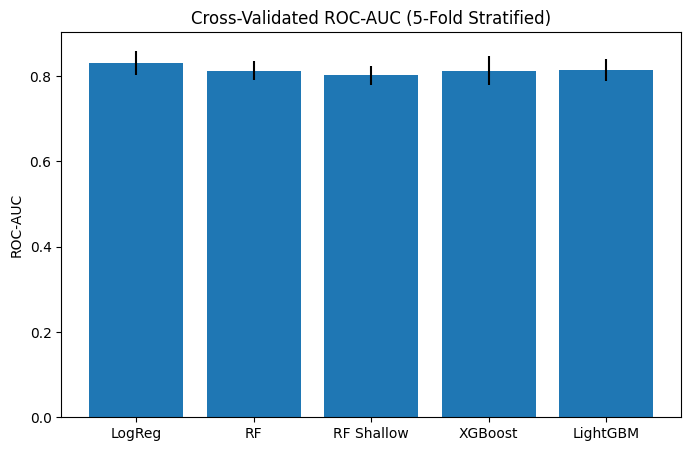

In [59]:
models = {
    "LogReg": lr_results,
    "RF": rf_results,
    "RF Shallow": rf2_results,
    "XGBoost": xgb_results,
    "LightGBM": lgbm_results
}

means = [v["test_roc_auc"].mean() for v in models.values()]
stds = [v["test_roc_auc"].std() for v in models.values()]

plt.figure(figsize=(8, 5))
plt.bar(models.keys(), means, yerr=stds)
plt.ylabel("ROC-AUC")
plt.title("Cross-Validated ROC-AUC (5-Fold Stratified)")
plt.show()


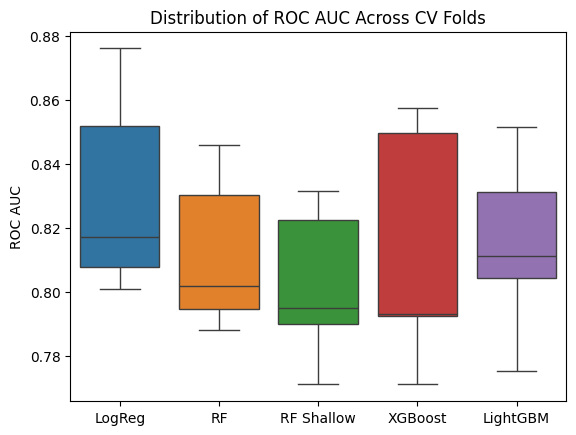

In [60]:
cv_df = pd.DataFrame({
    name: results["test_roc_auc"]
    for name, results in models.items()
})

sns.boxplot(data=cv_df)
plt.ylabel("ROC AUC")
plt.title("Distribution of ROC AUC Across CV Folds")
plt.show()


Across all evaluated models, logistic regression consistently provides the strongest performance with respect to the primary objective of attrition modelling: early and reliable identification of employees at risk of leaving. It achieves the highest recall among all methods while maintaining strong discriminative ability, as reflected by a high ROC-AUC and low variability across cross-validation folds. Its behaviour is stable and interpretable, making it well suited as a screening and risk-ranking model.

Tree-based ensemble methods exhibit a markedly different error profile. The unconstrained random forest prioritises precision over recall, resulting in many attrition cases being missed despite reasonable overall discrimination. Constraining the forest improves recall and stability, but not to the level achieved by the linear baseline. Gradient boosting and XGBoost further reinforce this pattern: both achieve high precision and strong ROC-AUC values, but consistently underperform in recall, limiting their usefulness as early-warning tools. These models tend to issue predictions only when confidence is high, leading to conservative behaviour that is misaligned with the asymmetric cost structure of attrition.

LightGBM partially mitigates this limitation by offering a more balanced precision–recall trade-off among non-linear models. It achieves the highest F1-score within the tree-based group and improves recall relative to other boosting approaches. However, it still falls short of the logistic regression baseline in terms of the primary objective of attrition detection.

Overall, increasing model complexity improves precision more readily than recall but does not enhance the ability to detect attrition cases in this dataset. The results suggest that the dominant challenge is not capturing complex non-linear patterns, but aligning model behaviour with the cost-sensitive nature of the problem. Consequently, the simpler linear model remains the most appropriate choice for this task, offering the best balance between performance, stability, and interpretability.

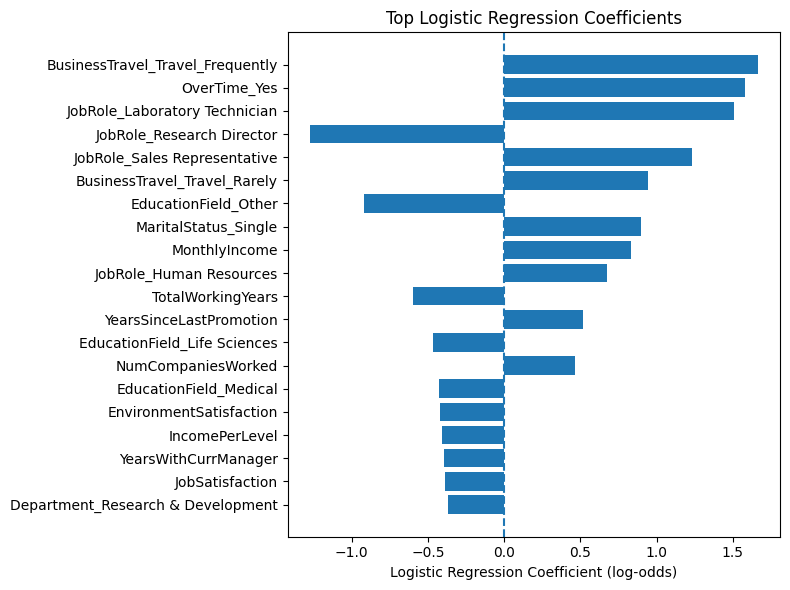

In [61]:
# After selecting logistic regression as the final model based on cross-validated performance, 
# the model is re-fitted on the training set and evaluated on the held-out validation set
# to obtain concrete performance diagnostics and visual summaries. Any later steps
# (coefficients, shap, calibration curves, threshold tuning, etc...)
# must be based on a single fitted model, not on CV folds.

from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

#Fit final model on the full training set
final_model.fit(X_train, y_train)

#Reconstruct feature names from the preprocessor
preprocessor = final_model.named_steps["preprocessor"]

# Categorical feature names after one-hot encoding
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

# Final feature name list: numeric + expanded categorical
feature_names = numeric_features + list(cat_feature_names)

#Extract coefficients from the logistic regression
log_reg = final_model.named_steps["model"]
coefficients = log_reg.coef_[0] 

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

#Select top features by absolute coefficient magnitude
coef_df["abs_coef"] = coef_df["coefficient"].abs()
top_n = 20
top_coef_df = coef_df.sort_values("abs_coef", ascending=False).head(top_n)

#Plot coefficients as a horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(top_coef_df["feature"], top_coef_df["coefficient"])
plt.axvline(0, linestyle="--")  # zero line
plt.xlabel("Logistic Regression Coefficient (log-odds)")
plt.title("Top Logistic Regression Coefficients")
plt.gca().invert_yaxis()  # largest magnitude at top
plt.tight_layout()
plt.show()



After selecting Logistic Regression as the final model based on cross-validated predictive performance, the following step is to investigate why the model produces its predicitons. In employee attrition analysis, this interpretability step is essential because the objective is not only to classify employees as “likely to leave” or “likely to stay”, but to understand the drivers of attrition risk in a way that can support human decision-making. for this reason, coefficient analysis is included as a core component of the modelling workflow. Logistic Regression offers a particularly appropriate framework for feature importance interpretation because it provides a direct and mathematically grounded link between input variables and predicted attrition probabilities. Unlike more complex models where "importance" may be distributed across non-linear interactions, Logistic Regresssion estimates a single weight (coefficient) for each feature that captures the direction and strenght of that feature's assoiation with attrition, conditional on all other variables in the model.

But why coefficients provide meaningful feature importance? LogReg algorithm models the probability of attrition through a linear combination of the input features. each coefficient represents the expected change in the log-odds of attrition associated with a one-unit increase in the feature, holding the others constant. as a result, coefficients naturally provide: directionality, whether a feature increases or decreases the likelihood of attrition; Magnitude, how strongly that feature influences risk relative to others; Comparability across features, if/when preprocessing is handled correctly.
This makes coefficient inspection a reliable method for identifying which factors appear most influential in predicting attrition. Importantly, this interpretation is not only descriptive. It refects the structure of the fitted predictive model and therefore captures relationships that contribute directly to classification performance.

However, the log-odds scale is not intuitive for non-technical audiences and requires explanation. Coefficeints are also sensitive to preprocessing decisions, particularly feature scaling and encoding choices. Additionally, coefficients may become difficult to interpret  when predictors are correlated, since collinearity can produce unstable or counter-intuitive weights even when the overall model predictions remain accurate. Finally, while coefficients indicate association within the fitted model, they do not directly mmeasure predictive reliance; a feature can have a large coefficient but still contribute little to out-of-sample performance if redundant information is present in other variables. For this reason, coefficient plots are best supported by permutation importance, which evaluates predictive contribution directly, and by odds ratios, which improve interpretability for reporting. (the plots mentioned will be further inspected in the feature importance chapter).

In [62]:
y_val_pred = final_model.predict(X_val)
y_val_prob = final_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred))
print("ROC AUC:", roc_auc_score(y_val, y_val_prob))
print(confusion_matrix(y_val, y_val_pred))


              precision    recall  f1-score   support

           0       0.94      0.80      0.86       247
           1       0.41      0.72      0.52        47

    accuracy                           0.79       294
   macro avg       0.67      0.76      0.69       294
weighted avg       0.85      0.79      0.81       294

ROC AUC: 0.8182444655009045
[[198  49]
 [ 13  34]]


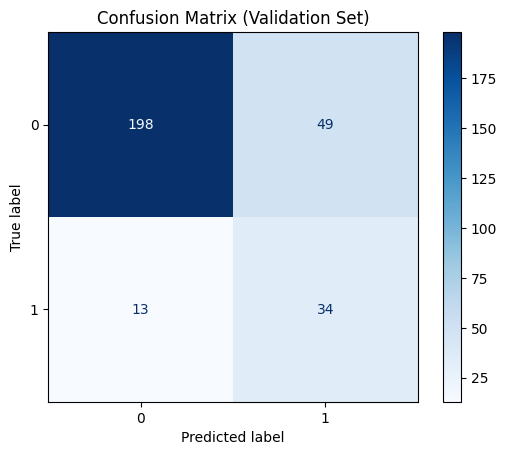

In [63]:
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_val,
    y_val,
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix (Validation Set)")
plt.show()


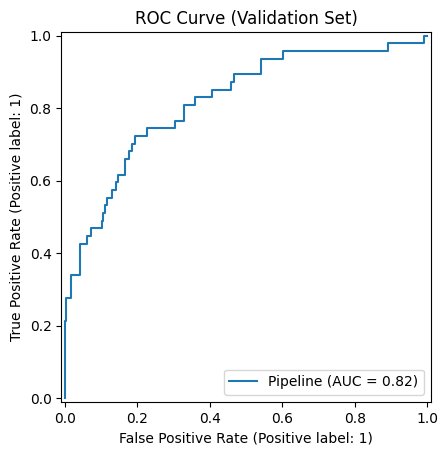

In [64]:
RocCurveDisplay.from_estimator(
    final_model,
    X_val,
    y_val
)
plt.title("ROC Curve (Validation Set)")
plt.show()


# Calibration

Calibration analysis examines the agreement between predicted probabilities and observed outcome frequencies. A model is well calibrated if, among all observations assigned a given predicted probability, the proportion of actual positive outcomes matches that probability. This property is distinct from discrimination, which measures how well a model separates classes and is typically assessed using metrics such as ROC-AUC.

In attrition modelling, predicted probabilities are often used to rank employees by risk, set intervention thresholds, or inform decision-making. In such contexts, reliable probability estimates are essential. A model may achieve strong discrimination and recall while still producing probabilities that are systematically overconfident or underconfident, particularly when class weighting is applied or when the class distribution is imbalanced.

The calibration curve provides a diagnostic view of this behaviour by grouping predictions into bins and comparing average predicted probabilities with observed attrition rates within each bin. Deviations from the ideal diagonal indicate systematic miscalibration. Evaluating calibration after final model selection ensures that the model’s probability outputs can be meaningfully interpreted and, if necessary, adjusted through post-hoc calibration methods before deployment or further analysis.

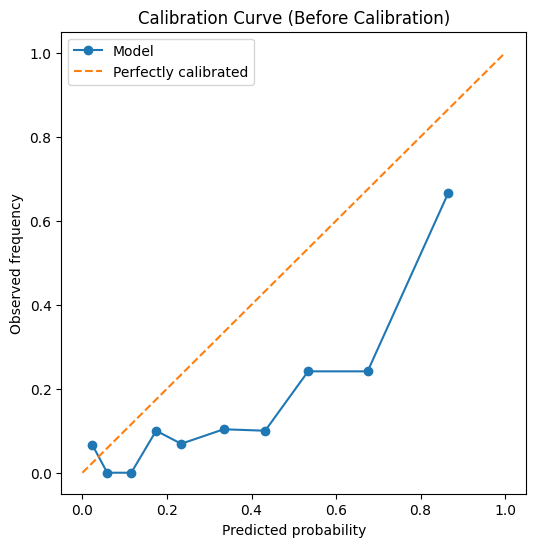

In [65]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve (Before Calibration)")
plt.legend()
plt.show()


While the selected logistic regression model demonstrates strong discriminative performance, as evidenced by its ROC-AUC and recall, discrimination alone does not guarantee that the predicted probabilities are reliable as estimates of attrition risk. In many applied settings, including employee attrition analysis, predicted probabilities are used not only for classification but also for ranking employees, selecting intervention thresholds, and supporting decision-making. In such cases, the numerical accuracy of probability estimates becomes an important model property.

To assess this aspect, a calibration curve is examined. The pre-calibration curve shows a systematic deviation from the diagonal corresponding to perfect calibration, with predicted probabilities consistently exceeding observed attrition frequencies. This indicates that the model is overconfident: employees assigned a given predicted risk tend to leave less frequently than implied by the predicted probability. This behaviour is expected in the presence of class imbalance and the use of class weighting, which modifies the optimisation objective to prioritise recall over probability accuracy.

The calibration curve shows that the logistic regression model systematically overestimates attrition risk across most probability ranges, indicating good ranking performance but miscalibrated probability estimates, particularly due to class weighting and class imbalance.

Given the systematic overestimation of attrition risk observed in the calibration curve, a post-hoc probability calibration is applied to adjust the predicted probabilities while preserving the model's discriminative performance

The miscalibration observed is smooth and monotonic across probability bins, suggesting that the underlying ranking of predictions is sound, but the probability scale is distorted. This pattern motivates the use of post-hoc probability calibration rather than model re-training. Specifically, sigmoid calibration (Platt scaling) is applied using cross-validated calibration folds to adjust the probability outputs while preserving the model’s discriminative structure and avoiding information leakage.

In [66]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    final_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)



CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['Age',
                                                                                    'DistanceFromHome',
                                                                                    'Education',
                                                                                    'EnvironmentSatisfaction',
                                                                                    'JobInvolvement',
                                                                                    'JobLevel',
                                                                                    'JobSatisfaction',
                                                                                    'MonthlyIncome',
                                                                                    'NumCompaniesWorked',
                                                                                    'Pe...
                                                                                    'YearsWithCurrManager',
                                                                                    'IncomePerLevel']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                   ('onehot',
                                                                                                    OneHotEncoder(drop='first',
                                                                                                                  handle_unknown='ignore'))]),
                                                                                   ['BusinessTravel',
                                                                                    'Department',
                                                                                    'EducationField',
                                                                                    'Gender',
                                                                                    'JobRole',
                                                                                    'MaritalStatus',
                                                                                    'OverTime'])])),
                                                 ('model',
                                                  LogisticRegression(class_weight='balanced',
                                                                     max_iter=1000))]))

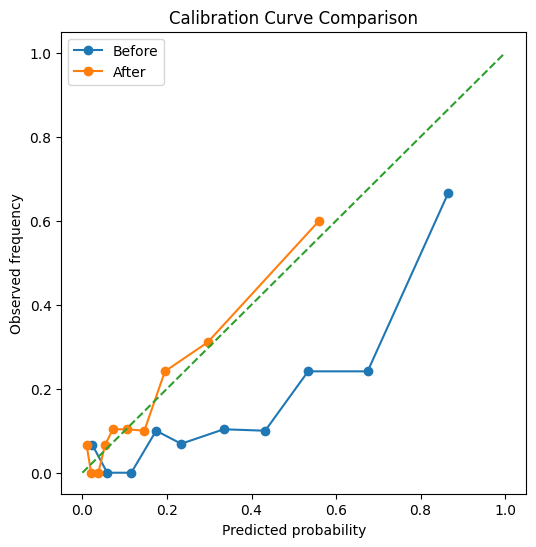

In [67]:
y_val_prob_cal = calibrated_model.predict_proba(X_val)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(
    y_val,
    y_val_prob_cal,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Before")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="After")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.show()


The calibration curve after sigmoid calibration shows a substantial improvement in alignment between predicted probabilities and observed attrition frequencies. Compared to the pre-calibration curve, the calibrated model’s predictions lie much closer to the diagonal, indicating that predicted risks now more accurately reflect empirical outcome rates across the probability range.

The most pronounced improvements occur in the low to medium probability regions, where the original model exhibited the strongest overestimation. In higher probability bins, calibration reduces overconfidence while maintaining the correct ordering of risk. This confirms that the calibration process corrects the probability scale without degrading the model’s ability to rank employees by attrition risk.

Importantly, the calibration procedure does not alter the underlying classifier or its decision boundaries. As a result, classification-oriented metrics such as recall and ROC-AUC are expected to remain largely unchanged. Instead, calibration improves the interpretability and reliability of probability estimates, enabling their use in downstream tasks such as threshold selection, risk communication, and policy analysis.

Overall, the calibration results demonstrate that post-hoc probability calibration is a necessary and effective step in transforming a high-performing classifier into a decision-support tool with numerically meaningful risk estimates.

With probability calibration applied, the predictive modelling phase is complete, yielding a final model with stable discriminative performance and numerically reliable probability estimates.

# Feature Importance

The following section focuses on interpreting the fitted logistic regression model to understand which features contribute most strongly to attrition risk and in which direction.
Interpretability analyses are conducted on the underlying logistic regression model, as probability calibration affects only the output scale and does not alter feature contributions or decision structure.

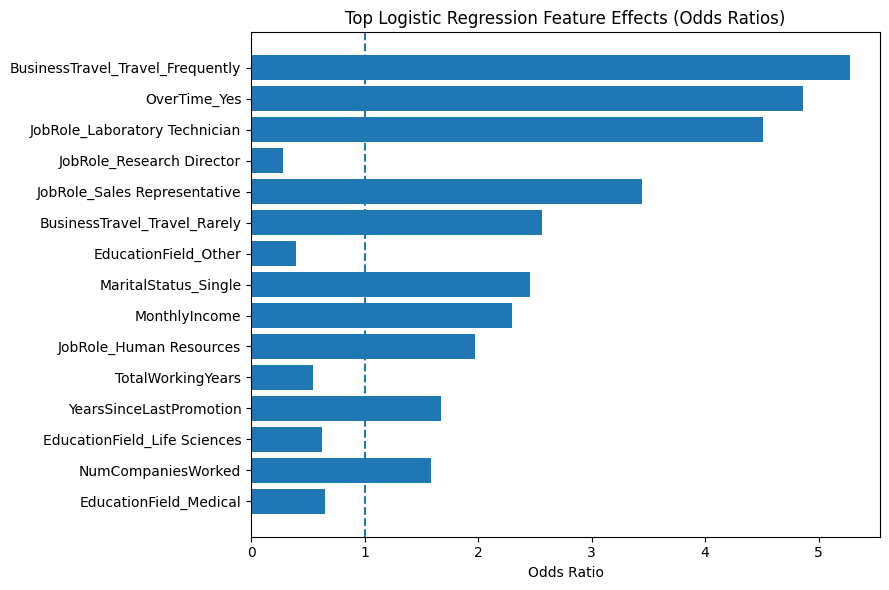

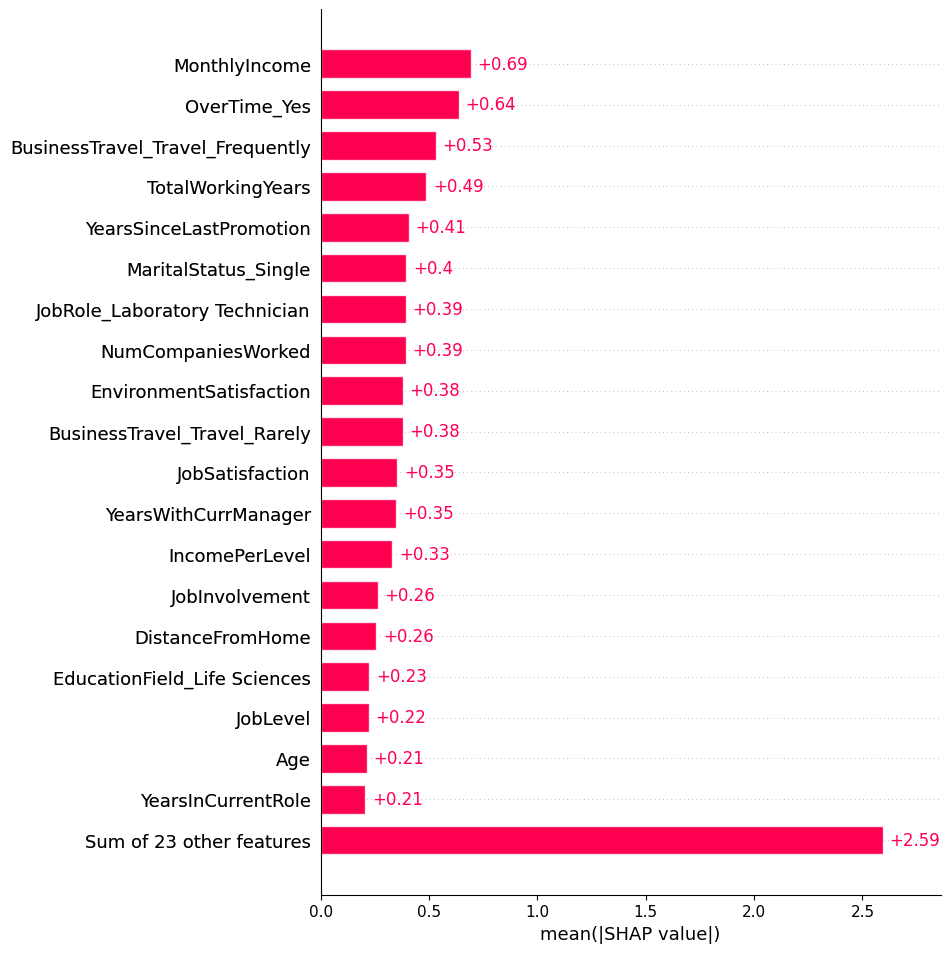

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Feature Importance (Logistic Regression)

# Logistic Regression is trained on the expanded design matrix produced by the
# preprocessing pipeline (scaled numeric features + one-hot encoded categoricals).
# For interpretability, the full list of transformed feature names is reconstructed
# and the features are mapped to the fitted model coefficients.

# Reconstruct feature names from the fitted preprocessor
ohe = (
    final_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_feature_names)

# Extract coefficients and compute odds ratios
coefficients = final_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Odds Ratio interpretation:
# OR > 1  -> increases attrition risk
# OR < 1  -> decreases attrition risk
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

# Sort features by absolute coefficient magnitude (strongest effects first)
coef_df = coef_df.reindex(
    coef_df["coefficient"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

#  Plot: Top effects using Odds Ratios (best for first-sight interpretability)
top_n = 15
top_or = coef_df.head(top_n).copy()

plt.figure(figsize=(9, 6))
plt.barh(top_or["feature"][::-1], top_or["odds_ratio"][::-1])
plt.axvline(1, linestyle="--")  # OR = 1 (no effect)
plt.xlabel("Odds Ratio")
plt.title("Top Logistic Regression Feature Effects (Odds Ratios)")
plt.tight_layout()
plt.show()

# ===============================
# SHAP Global Feature Importance (Magnitude)
# ===============================
# SHAP values provide a consistent measure of global importance based on the
# average absolute contribution of each feature to the model output.

# Transform train/validation data into the expanded design matrix
X_train_processed = final_model.named_steps["preprocessor"].transform(X_train)
X_val_processed = final_model.named_steps["preprocessor"].transform(X_val)

# Create SHAP explainer (suited for linear models)
explainer = shap.LinearExplainer(
    final_model.named_steps["model"],
    X_train_processed,
    feature_names=feature_names
)

# Compute SHAP values on validation set (recommended for unbiased interpretation)
shap_values_val = explainer(X_val_processed)

# Plot global importance as a ranked bar plot (mean absolute SHAP values)
shap.plots.bar(shap_values_val, max_display=20)


Logistic Regression Odds Ratios (Feature Effects) - Plot 1.

The odds ratio plot is derived from the coefficient plot by exponentiating each coefficient to obtain an interpretable effect size where values above one indicate increased odds of attrition and values below one indicate decreased odds. This plot retains the same underlying information as the coefficient plot but communicates results in a form that is more accessible for reporting and HR interpretation.

As with coefficients, odds ratios provide directional insight but still operate at the level of individual encoded features. Therefore, while they mix categorical and numerical inputs in one visualisation, they do not provide a fully comparable ranking of categorical versus numerical variables at the original feature level. For this reason, odds ratios are best used for directional interpretation and actionable explanations, and should be complemented by global ranking methods such as grouped SHAP or permutation importance.


Shap Feature Importance Ranking (ungrouped) - Plot 2

The SHAP global feature ranking plot summarises the average magnitude of feature contribution across predictions. SHAP values (based on Shapely values from cooperative game theory) aim to quantify how much each feature contributes to moving a model's prediction away from the baseline. In the global ranking plot, the importance score is often computed as the mean absolute SHAP value, which quantifies typical contribution size but does not necessarily provide clear directional insight.
The purpose of this plot is to identify which specific features most strongly influence the model's predictions on average. Unlike coefficients, which are parameters of the model, SHAP describes how much features actually contribute to prediction across individuals. This makes SHAP useful as a model-agnostic explanation framework and provides interpretability, as it is widely used in applied machine learning.
The principal weakness of ungrouped SHAP in this dataset is the one-hot encoding structure. Categorical variables such as job role or education field are expanded into many indicator columns, and ungrouped SHAP importance can therefore become fragmented across categories. This makes interpretation less clear because the importance of a high-level factor is spread across multiple dummy variables. Additionally, global SHAP bar plots typically show only magnitude, which can cause confusion if the reader expects positive values to mean “risk increasing.” In this setting, the ungrouped SHAP ranking is best supported by grouped SHAP importance, which restores interpretability at the concept level, and by odds ratios, which provide clear direction of effect.

One last consideration, when applied directly to one-hot encoded variables, this ranking is fragmented across many category indicators, making it harder to interpret categorical variables as coherent units. As a result, while SHAP can technically rank numerical and categorical columns together, the comparison is not fully balanced unless categorical contributions are aggregated back to their original feature groups.

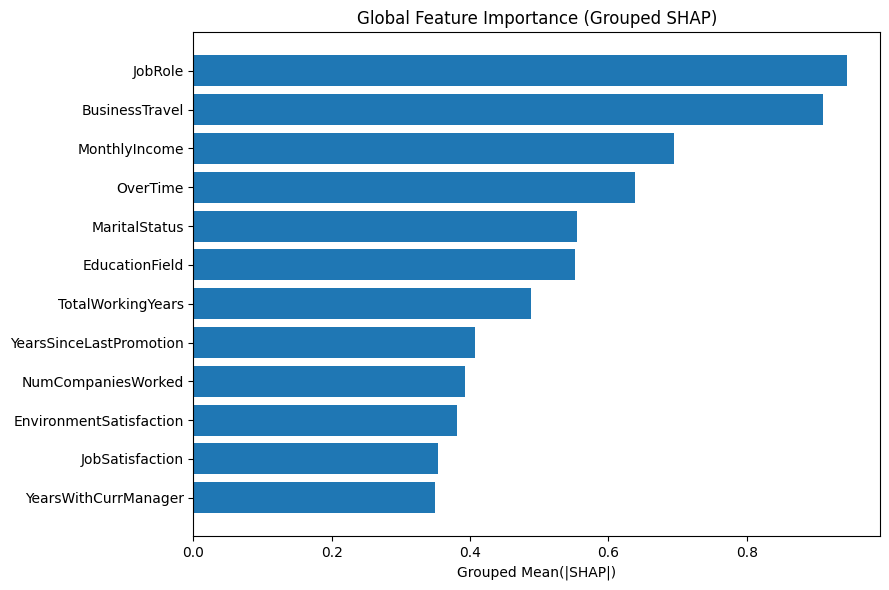

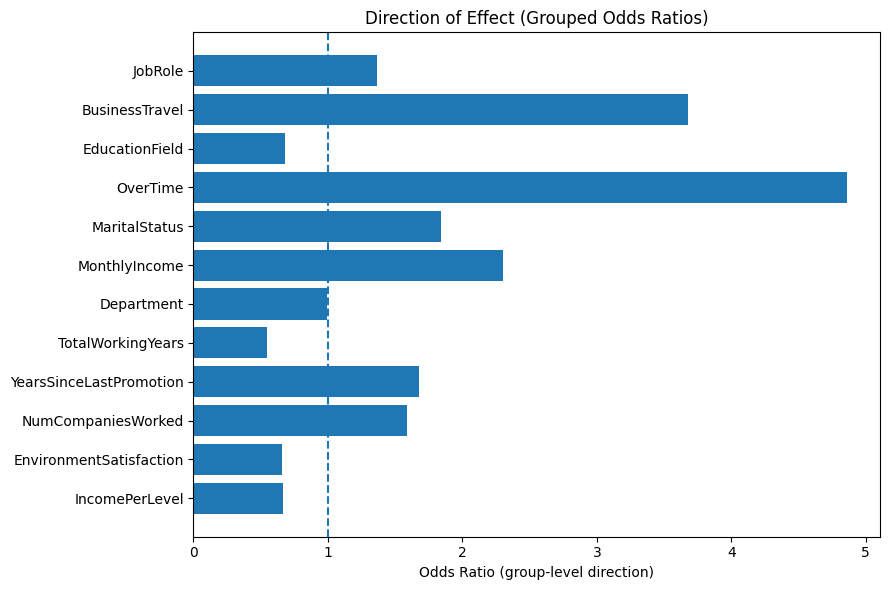

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

ohe = (
    final_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

# Helper: group one-hot encoded columns back to original categorical variable
def group_feature_name(fname: str) -> str:
    for cat in categorical_features:
        if fname.startswith(f"{cat}_"):
            return cat
    return fname  # numeric stays the same

# ===============================
# 2) SHAP (Global Importance) - GROUPED
# ===============================
# SHAP answers: "Which features matter most overall?"

X_train_processed = final_model.named_steps["preprocessor"].transform(X_train)
X_val_processed = final_model.named_steps["preprocessor"].transform(X_val)

explainer = shap.LinearExplainer(
    final_model.named_steps["model"],
    X_train_processed,
    feature_names=feature_names
)

shap_values_val = explainer(X_val_processed)

# Mean absolute SHAP per feature
shap_abs_mean = np.abs(shap_values_val.values).mean(axis=0)

shap_imp_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": shap_abs_mean
})
shap_imp_df["group"] = shap_imp_df["feature"].apply(group_feature_name)

# Grouped importance = sum of the one-hot components
grouped_shap = (
    shap_imp_df.groupby("group", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)

# Plot top grouped SHAP importance
top_n = 12
top_grouped_shap = grouped_shap.head(top_n)

plt.figure(figsize=(9, 6))
plt.barh(top_grouped_shap["group"][::-1], top_grouped_shap["mean_abs_shap"][::-1])
plt.xlabel("Grouped Mean(|SHAP|)")
plt.title("Global Feature Importance (Grouped SHAP)")
plt.tight_layout()
plt.show()

# ===============================
# 3) Logistic Regression Direction - Odds Ratio bar plot
# ===============================
# Odds ratios answer: "Does this feature increase or decrease attrition risk?"

coef = final_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

coef_df["group"] = coef_df["feature"].apply(group_feature_name)

# For each group:
# - take the average coefficient sign direction (mean)
# - take magnitude as sum(|coef|) for strength
grouped_coef = (
    coef_df.assign(abs_coef=np.abs(coef_df["coefficient"]))
    .groupby("group", as_index=False)
    .agg(
        mean_coef=("coefficient", "mean"),
        strength=("abs_coef", "sum")
    )
)

# Convert mean coefficient to odds ratio
grouped_coef["odds_ratio"] = np.exp(grouped_coef["mean_coef"])

# Sort by strength (most influential groups first)
grouped_coef = grouped_coef.sort_values("strength", ascending=False)

top_grouped_coef = grouped_coef.head(top_n)

plt.figure(figsize=(9, 6))
plt.barh(top_grouped_coef["group"][::-1], top_grouped_coef["odds_ratio"][::-1])
plt.axvline(1, linestyle="--")
plt.xlabel("Odds Ratio (group-level direction)")
plt.title("Direction of Effect (Grouped Odds Ratios)")
plt.tight_layout()
plt.show()


Global Feature Importance (Grouped SHAP) - Plot 3

Grouped SHAP addresses the limitations of the previous Ungrouped SHAP by aggregating SHAP contributions across al one-hot encoded categories belonging to the same original feature group. For example, all job role categories are combined into a single “JobRole” importance score. This produces a compact ranking of high-level feature groups such as job role, business travel, overtime, and income.

The key limitation of grouped SHAP is that it provides importance magnitude but not direction. A high-ranking group indicates strong model reliance but does not indicate whether the group generally increases or reduces attrition risk, particularly when the group contains categories with mixed effects. For example, some job roles may increase attrition risk while others are protective, meaning that the aggregate importance does not map to a single directional conclusion. Grouped SHAP is best supported by odds ratio plots, which give direction at feature or category level, and by permutation importance, which confirms performance reliance.


Direction Of Effect (Grouped Odds Ratios)

The grouped direction odds ratio plot attempts to summarise whether each feature group tends to increase or reduce attrition risk in aggregate. This is typically constructed by aggregating or summarising odds ratios across categories belonging to the same high-level feature.

The purpose of this plot is to complement grouped SHAP by adding a directional interpretation at the group level. It offers an appealing high-level narrative because it allows the report to state not only that a group is important, but also whether it tends to push predictions toward attrition or retention.

However, this plot must be treated carefully because groups often contain categories with opposing effects. Aggregating those effects into a single directional number can oversimplify the underlying dynamics. In particular, job role and education field frequently include both high-risk and low-risk categories, and a single group-level odds ratio may hide this heterogeneity. For this reason, this plot is better positioned as a supporting visual rather than a primary result. It is best supported by the odds ratio plot for specific categories and by grouped SHAP for importance magnitude.



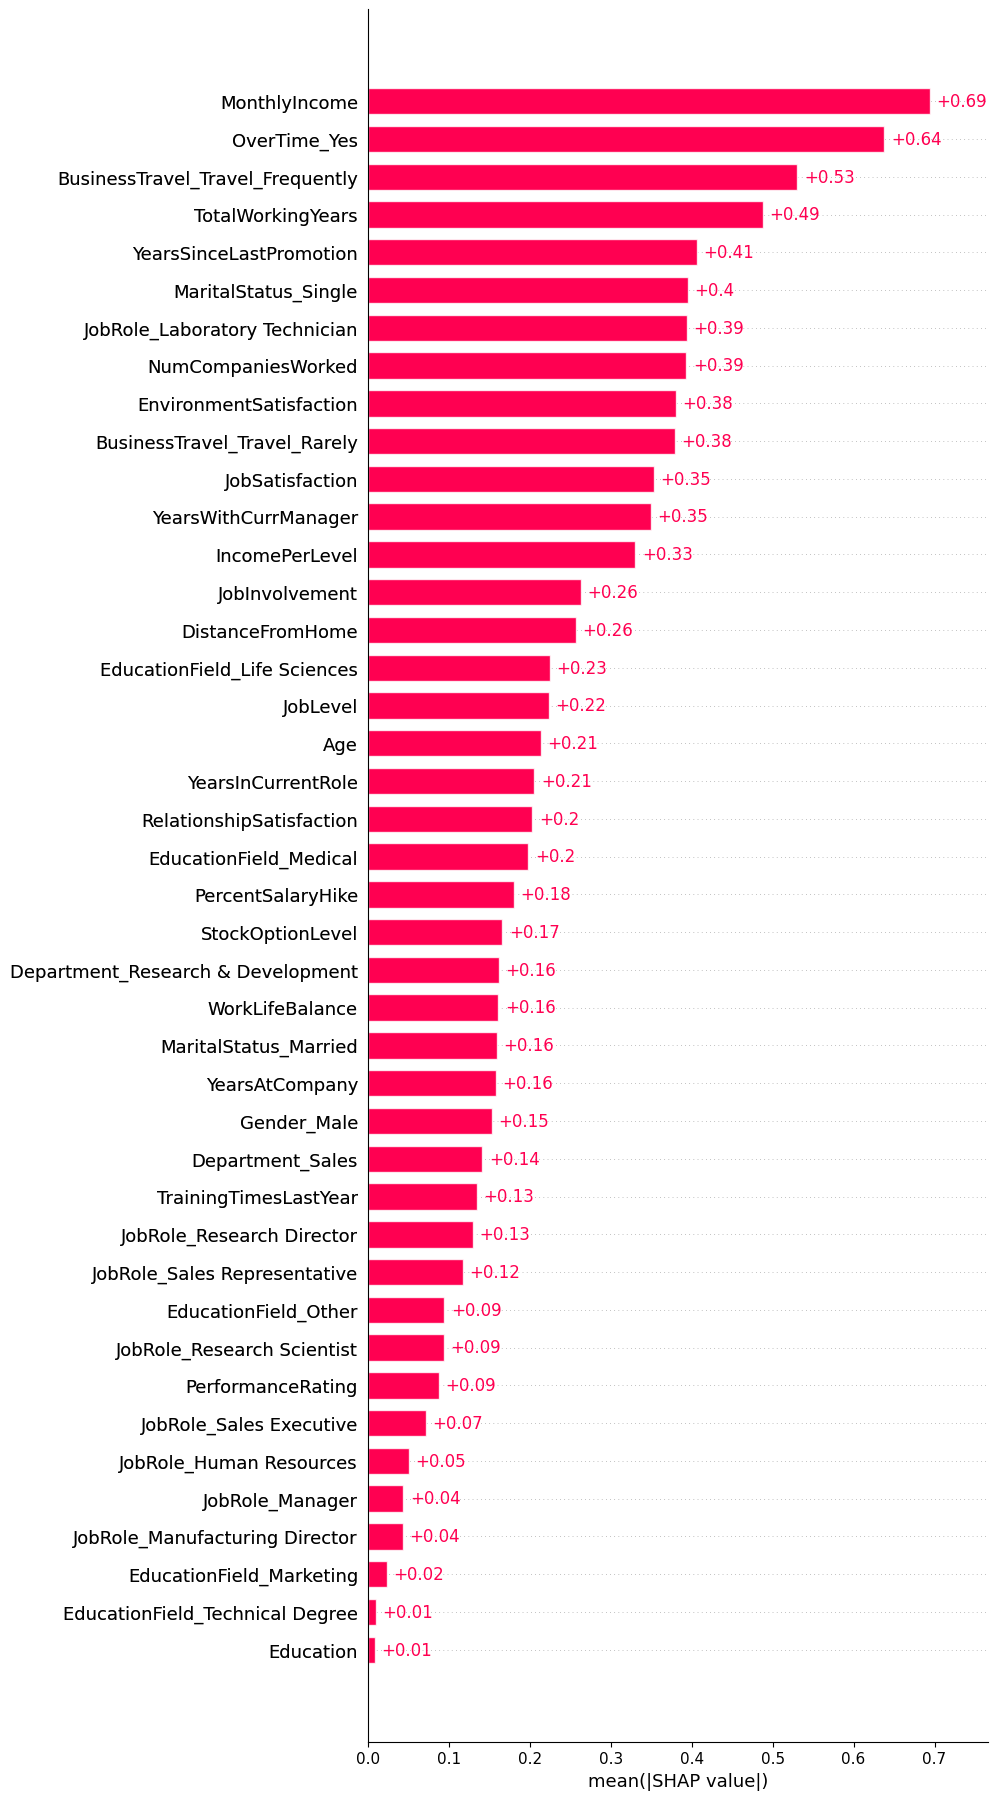

In [70]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

ohe = (
    final_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

X_train_processed = final_model.named_steps["preprocessor"].transform(X_train)
X_val_processed = final_model.named_steps["preprocessor"].transform(X_val)

explainer = shap.LinearExplainer(
    final_model.named_steps["model"],
    X_train_processed,
    feature_names=feature_names
)

shap_values_val = explainer(X_val_processed)

shap.plots.bar(shap_values_val, max_display=len(feature_names))


Shap Feature Importance Ranking (ungrouped, expanded) - Plot 4

Identical to Plot 2, but expanded to visualize every feature.

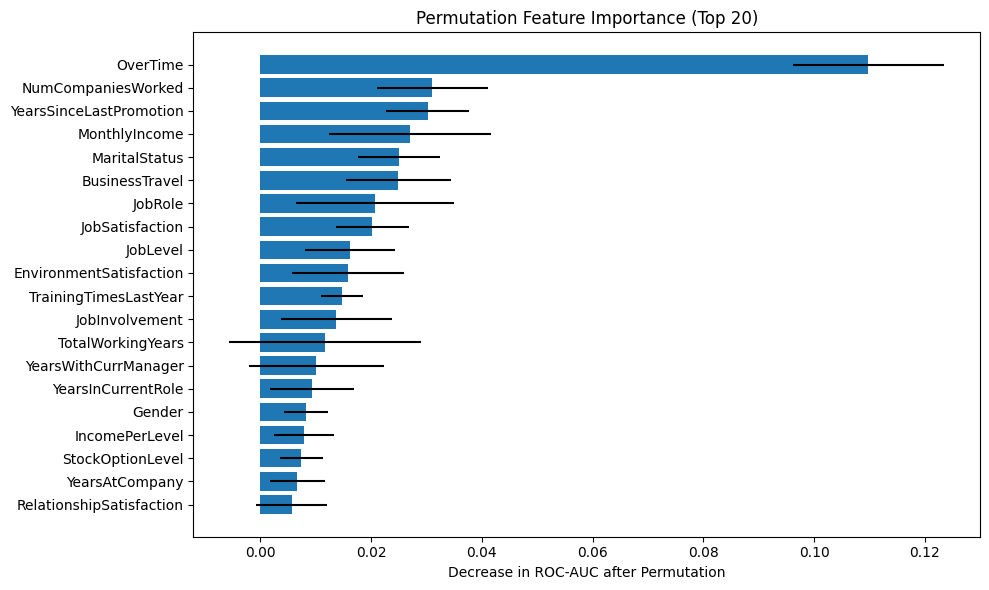

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Compute permutation importance on the validation set
perm = permutation_importance(
    final_model,
    X_val,
    y_val,
    n_repeats=15,
    random_state=42,
    scoring="roc_auc"
)

# Create a dataframe of importances
perm_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

# Plot all features (or limit to top N)
top_n = 20
plot_df = perm_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"][::-1], plot_df["importance_mean"][::-1], xerr=plot_df["importance_std"][::-1])
plt.xlabel("Decrease in ROC-AUC after Permutation")
plt.title(f"Permutation Feature Importance (Top {top_n})")
plt.tight_layout()
plt.show()


Permutation importance measures the decrease in predictive performance when the values of a given feature are randomly shuffled. By breaking the relationship between that feature and the target, the method estimates how much the model depends on that feature for accurate predictions. In the context of this analysis, importance is expressed as the drop in ROC-AUC, which makes the result directly linked to discriminative performance.

The purpose of permutation importance is to quantify predictive reliance. Unlike coefficients and odds ratios, which describe association patterns in the fitted model, permutation importance answers whether a feature meaningfully improves out-of-sample prediction quality. It therefore provides a performance-based validation of interpretability findings and strengthens the argument that the identified drivers are not only interpretable but also operationally relevant to prediction accuracy.

Permutation importance does not provide direction of effect; it cannot distinguish whether a feature increases or decreases attrition risk, only whether it is valuable for prediction. It is also sensitive to correlated predictors. When multiple variables share similar information, permuting one may not substantially reduce performance because the model can still rely on correlated alternatives. This can cause important features to appear less influential than they truly are, as importance becomes distributed across correlated sets of predictors. Despite these limitations, permutation importance remains one of the most defensible global importance measures and is best supported by odds ratios to restore direction and by grouped SHAP to link predictive reliance back to explainability.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


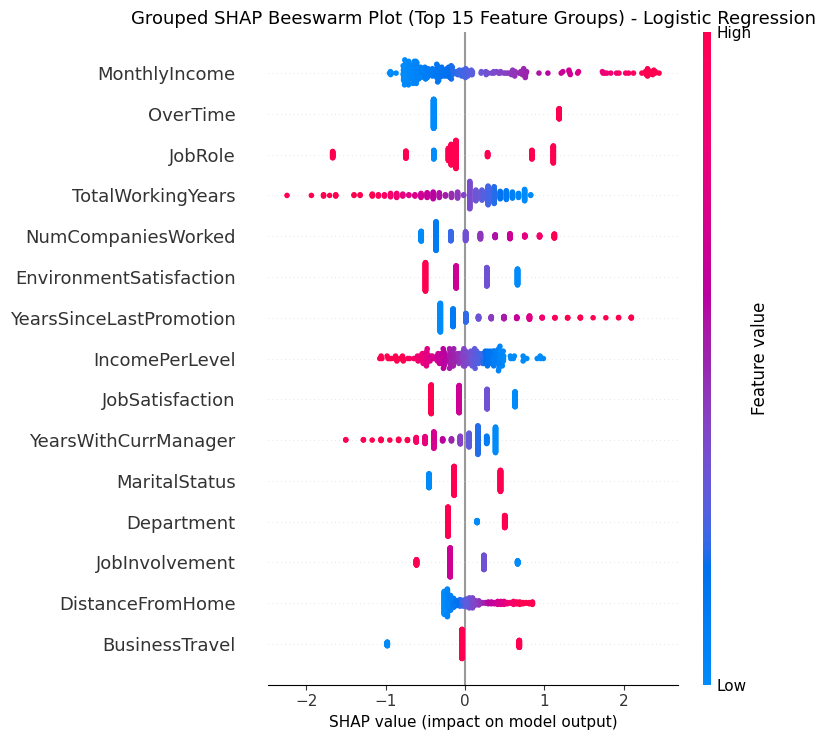

In [72]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

shap.initjs()

# -----------------------------
# 1) Extract objects
# -----------------------------
preprocessor = final_model.named_steps["preprocessor"]
model = final_model.named_steps["model"]

# Use validation set for explanations (more honest than training set)
X_explain = X_val.copy()

# Transform using fitted preprocessor
X_enc = preprocessor.transform(X_explain)

# Feature names after preprocessing
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
encoded_feature_names = numeric_features + list(cat_feature_names)

# Dense dataframe
X_enc_df = pd.DataFrame(
    X_enc.toarray() if hasattr(X_enc, "toarray") else X_enc,
    columns=encoded_feature_names
)

# -----------------------------
# 2) Compute SHAP values (LinearExplainer for Logistic Regression)
# -----------------------------
explainer = shap.LinearExplainer(model, X_enc_df, feature_perturbation="interventional")
shap_values = explainer(X_enc_df)  # shap.Explanation

shap_df = pd.DataFrame(shap_values.values, columns=encoded_feature_names)

# -----------------------------
# 3) Build mapping: encoded column -> original feature group
# -----------------------------
def feature_group(colname):
    # numeric features stay as themselves
    if colname in numeric_features:
        return colname

    # one-hot encoded columns look like "JobRole_Sales Representative"
    # group by prefix before first "_"
    if "_" in colname:
        return colname.split("_")[0]

    return colname

group_map = {c: feature_group(c) for c in encoded_feature_names}
groups = sorted(set(group_map.values()))

# -----------------------------
# 4) Aggregate SHAP values by group (sum of contributions)
# -----------------------------
grouped_shap_df = pd.DataFrame(index=shap_df.index)

for g in groups:
    cols_in_group = [c for c in encoded_feature_names if group_map[c] == g]
    grouped_shap_df[g] = shap_df[cols_in_group].sum(axis=1)

# -----------------------------
# 5) Aggregate feature "values" by group (mean for one-hot groups)
# -----------------------------
# For numeric groups: keep the numeric value (already scaled)
# For categorical groups (many dummies): mean gives a stable 0..1 scale for plotting colours
grouped_X_df = pd.DataFrame(index=X_enc_df.index)

for g in groups:
    cols_in_group = [c for c in encoded_feature_names if group_map[c] == g]
    if g in numeric_features:
        grouped_X_df[g] = X_enc_df[g]
    else:
        grouped_X_df[g] = X_enc_df[cols_in_group].mean(axis=1)

# -----------------------------
# 6) Keep Top N groups for readability
# -----------------------------
mean_abs_group_shap = grouped_shap_df.abs().mean(axis=0).sort_values(ascending=False)

top_n = 15  # recommended 10-20 for readability
top_groups = mean_abs_group_shap.head(top_n).index.tolist()

grouped_shap_top = grouped_shap_df[top_groups]
grouped_X_top = grouped_X_df[top_groups]

# -----------------------------
# 7) Plot grouped SHAP beeswarm
# -----------------------------
grouped_expl = shap.Explanation(
    values=grouped_shap_top.values,
    base_values=shap_values.base_values,
    data=grouped_X_top.values,
    feature_names=top_groups
)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(grouped_expl, max_display=top_n, show=False)
plt.title(f"Grouped SHAP Beeswarm Plot (Top {top_n} Feature Groups) - Logistic Regression", fontsize=13)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.show()


The grouped SHAP beeswarm plot provides a global, feature-level explanation of the fitted logistic regression model by showing how each feature group contributes to attrition predictions across all employees in the validation set. In this plot, feature groups are ordered from top to bottom according to their overall importance, measured by the average absolute SHAP value. This ranking indicates which variables the model relies on most when producing predictions, while the horizontal spread of points shows the magnitude and variability of impact across individuals.

The x-axis represents the SHAP value, which corresponds to the contribution of a feature group to the model output relative to the baseline prediction. Positive SHAP values indicate that the feature group pushes the prediction towards attrition, whereas negative values push the prediction towards non-attrition. Each dot corresponds to one employee, meaning that the distribution of points for a feature group reflects how differently that feature influences predictions for different individuals. A narrow cluster around zero suggests a weak or stable effect, while a wider spread indicates a feature group with strong discriminative influence.

It is also important to acknowledge that, while the grouped SHAP beeswarm provides a clear global ranking of feature groups, it is inherently limited in its interpretability for categorical variables. This is because categorical predictors such as JobRole, BusinessTravel, MaritalStatus, Department, and EducationField do not possess a natural “high versus low” scale, meaning the beeswarm colour encoding cannot be interpreted in the same way as it can for continuous numeric variables. As a result, the grouped beeswarm can confirm that a categorical feature group is influential, but it cannot directly reveal which specific categories within that feature increase attrition risk and which are protective.

To address this limitation and provide more context, the subsequent analysis therefore includes additional categorical-specific visualisations that decompose each categorical feature into its individual categories and report the mean SHAP contribution per category. These plots allow the categorical effects to be interpreted directionally by identifying which levels of a categorical predictor systematically push the model towards higher attrition predictions and which levels reduce predicted attrition probability. This complementary step ensures that the global insights from grouped SHAP are supported by more granular, category-level explanations that are both interpretable and actionable.

In [73]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Extract fitted pieces
preprocessor = final_model.named_steps["preprocessor"]
model = final_model.named_steps["model"]

# Transform validation set
X_enc = preprocessor.transform(X_val)

# Feature names after preprocessing
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
encoded_feature_names = numeric_features + list(cat_feature_names)

# Dense dataframe for SHAP
X_enc_df = pd.DataFrame(
    X_enc.toarray() if hasattr(X_enc, "toarray") else X_enc,
    columns=encoded_feature_names
)

# SHAP for logistic regression
explainer = shap.LinearExplainer(model, X_enc_df, feature_perturbation="interventional")
shap_values = explainer(X_enc_df)

# SHAP values as DataFrame (one column per encoded feature)
shap_df = pd.DataFrame(shap_values.values, columns=encoded_feature_names)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [74]:
def plot_categorical_shap_effect(cat_feature, X_original, shap_df, top_k=None, min_count=10):
    """
    cat_feature: name of the categorical variable (e.g., 'JobRole')
    X_original: original X_val dataframe (not encoded)
    shap_df: SHAP values dataframe (columns = one-hot encoded feature names)
    top_k: if not None, only show top_k categories by absolute mean SHAP (keeps plot readable)
    min_count: filters rare categories with too few samples
    """
    # Find one-hot columns belonging to this categorical variable
    cols = [c for c in shap_df.columns if c.startswith(f"{cat_feature}_")]

    if len(cols) == 0:
        print(f"[SKIP] No one-hot columns found for {cat_feature}")
        return None

    # Total SHAP contribution from this categorical feature (sum of its one-hot columns)
    shap_total = shap_df[cols].sum(axis=1)

    df = pd.DataFrame({
        cat_feature: X_original[cat_feature].astype(str).values,
        "SHAP": shap_total.values
    })

    # Summary stats
    summary = df.groupby(cat_feature)["SHAP"].agg(["mean", "median", "count", "std"])
    summary = summary[summary["count"] >= min_count].copy()

    if summary.empty:
        print(f"[SKIP] {cat_feature}: no categories left after min_count={min_count}")
        return None

    # Optional: keep only top_k most influential categories
    if top_k is not None and len(summary) > top_k:
        summary["abs_mean"] = summary["mean"].abs()
        summary = summary.sort_values("abs_mean", ascending=False).head(top_k)
        summary = summary.sort_values("mean", ascending=True)

    else:
        summary = summary.sort_values("mean", ascending=True)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(summary.index, summary["mean"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Mean SHAP value (positive → increases attrition prediction)")
    plt.title(f"{cat_feature}: Category Effects (Mean SHAP Contribution)")
    plt.tight_layout()
    plt.show()

    return summary


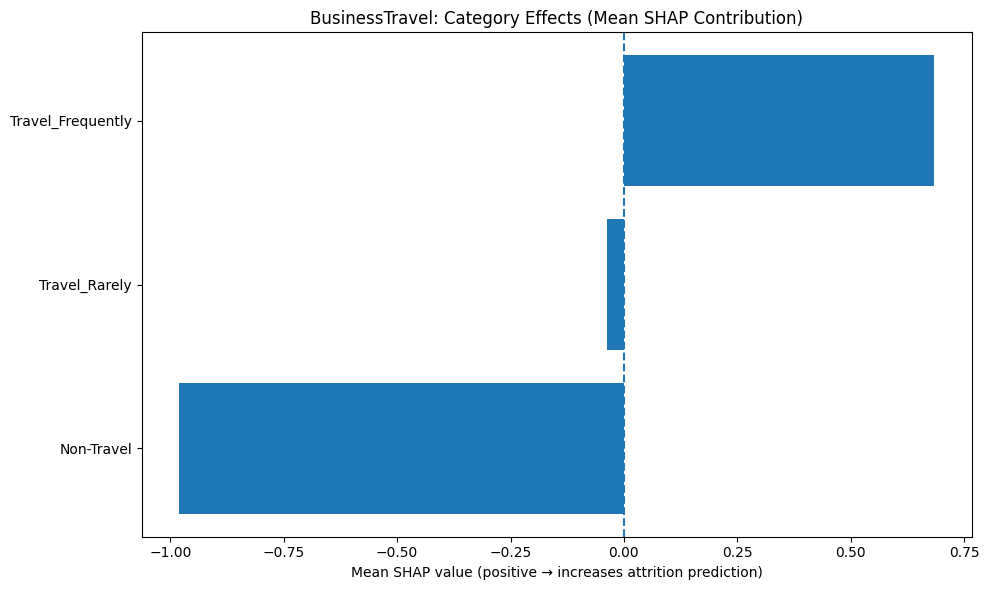

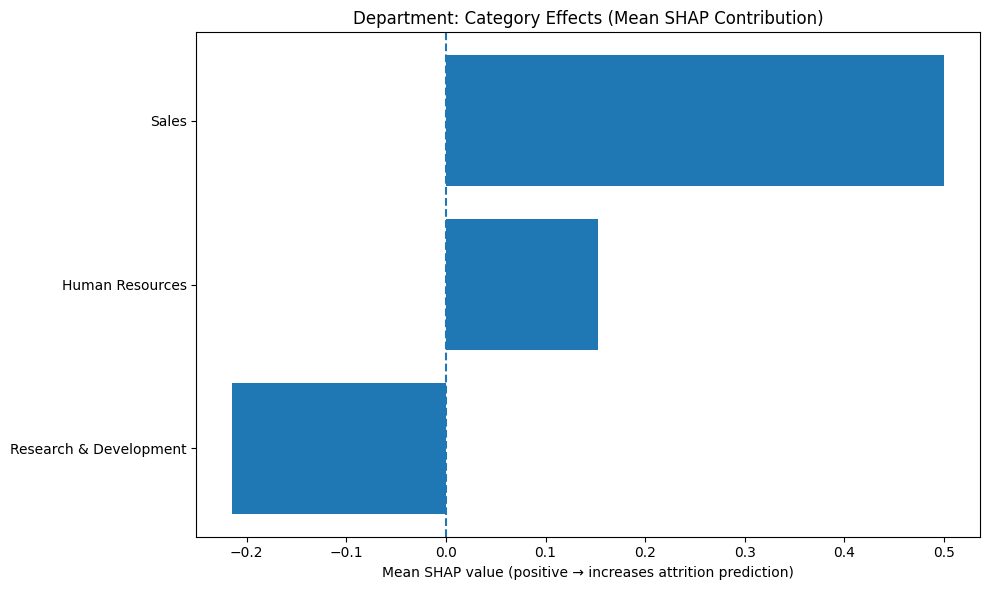

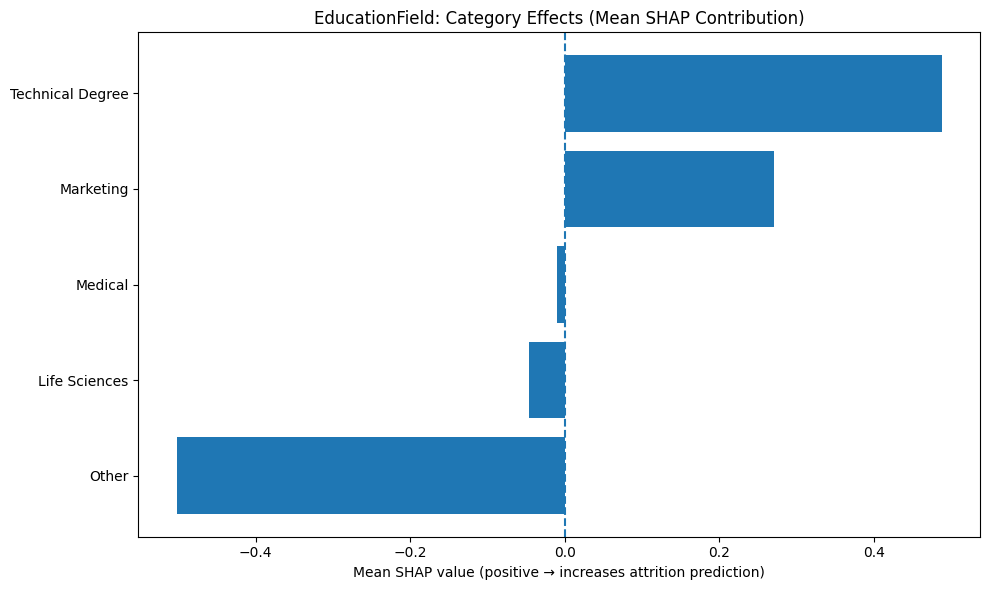

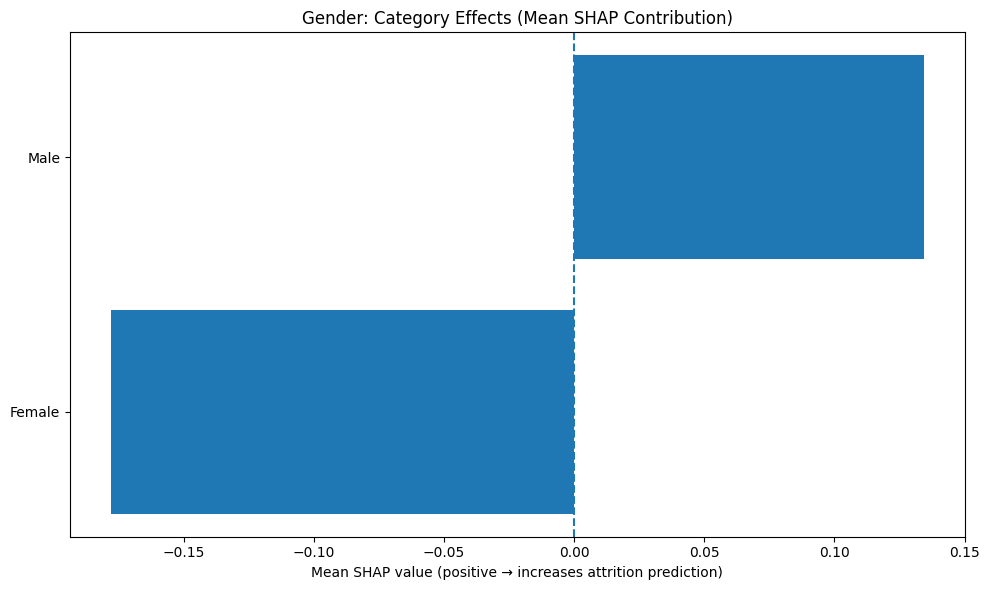

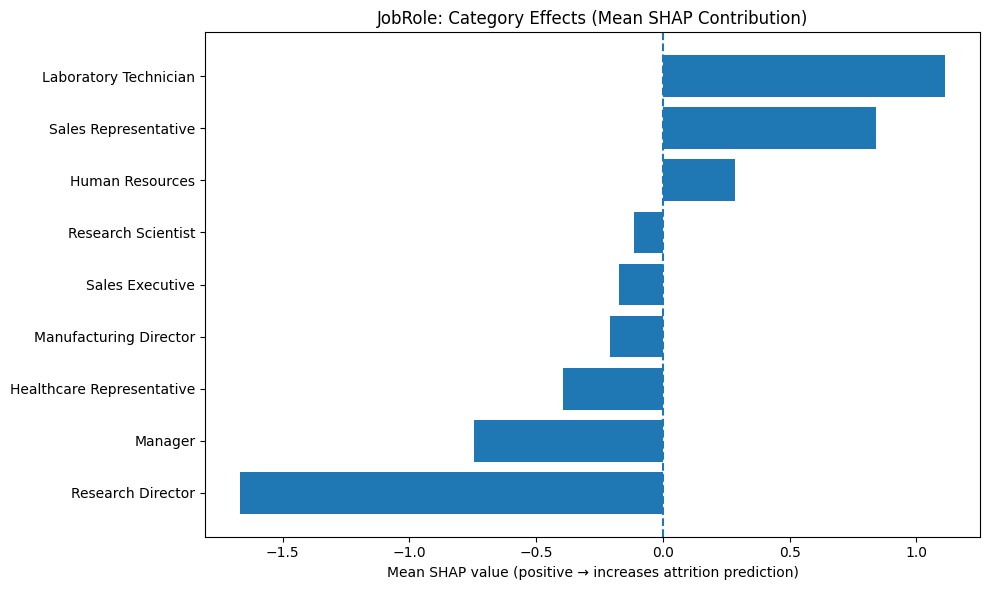

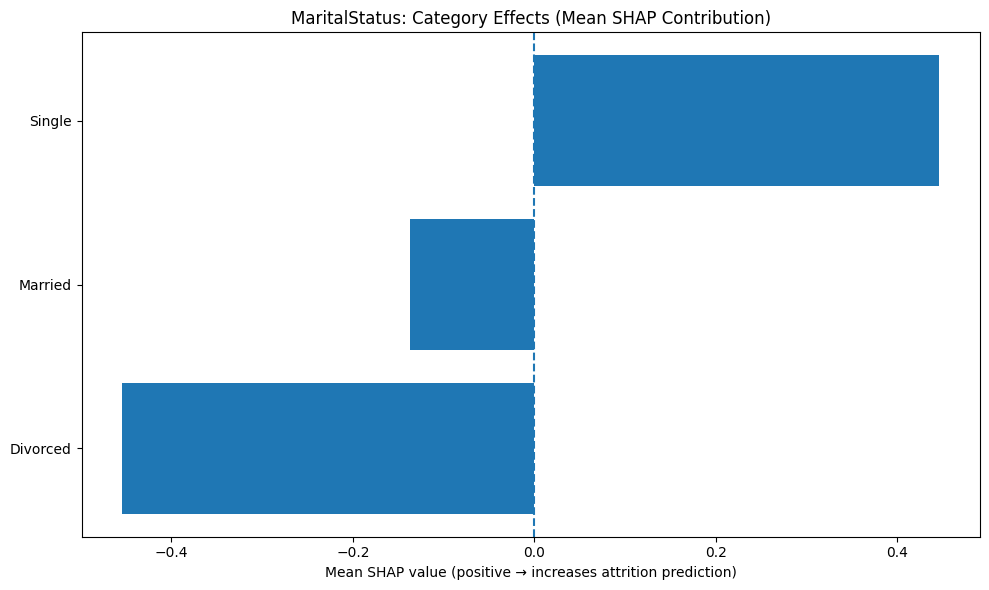

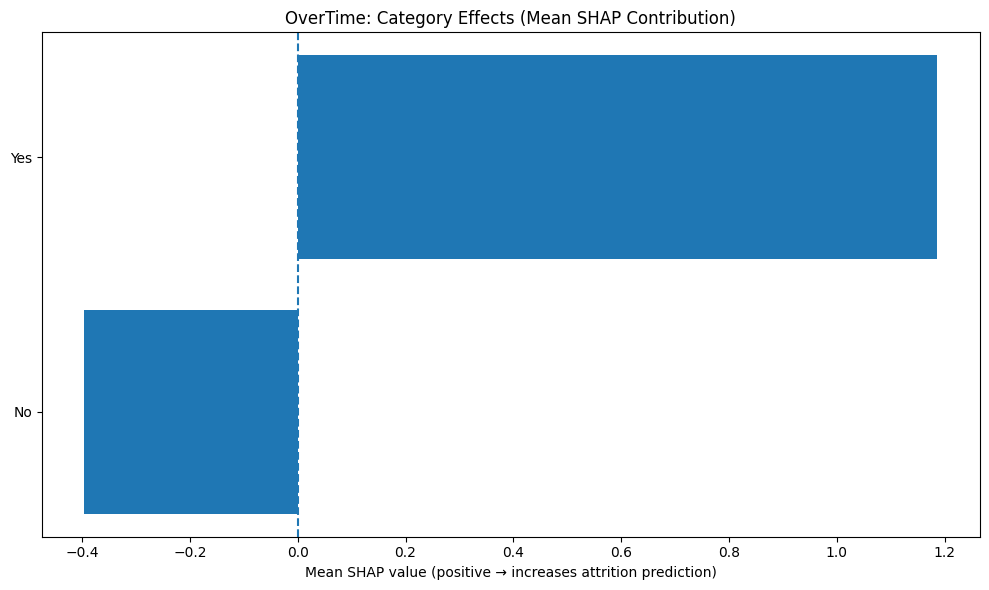

In [75]:
all_cat_summaries = {}

for cat in categorical_features:
    summary = plot_categorical_shap_effect(
        cat_feature=cat,
        X_original=X_val,
        shap_df=shap_df,
        top_k=12,      # keeps plots readable (adjust)
        min_count=10   # avoids noisy tiny groups
    )
    if summary is not None:
        all_cat_summaries[cat] = summary


**Diagnostic "Sanity check experiment"**.
An evaluation of whether the engineered feature 'IncomePerLevel' affects the evaluation or interpretability, or neither.

In [76]:
X = X.copy()
X["IncomePerLevel"] = X["MonthlyIncome"] / X["JobLevel"]


In [77]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

def build_preprocessor(num_feats, cat_feats):
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_scaled, num_feats),
            ("cat", categorical_transformer, cat_feats)
        ]
    )

def evaluate_variant(X_variant, y, num_feats, cat_feats, label):
    preprocessor = build_preprocessor(num_feats, cat_feats)

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])

    results = cross_validate(
        model,
        X_variant,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    return {
        "Variant": label,
        "ROC_AUC": f"{results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}",
        "RECALL": f"{results['test_recall'].mean():.3f} ± {results['test_recall'].std():.3f}",
        "PRECISION": f"{results['test_precision'].mean():.3f} ± {results['test_precision'].std():.3f}",
        "F1": f"{results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}",
    }


In [78]:
base_numeric = [
    "Age", "DistanceFromHome", "Education",
    "EnvironmentSatisfaction", "JobInvolvement",
    "JobLevel", "JobSatisfaction", "MonthlyIncome", "NumCompaniesWorked", "PercentSalaryHike",
    "PerformanceRating", "RelationshipSatisfaction",
    "StockOptionLevel", "TotalWorkingYears",
    "TrainingTimesLastYear", "WorkLifeBalance",
    "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager"
]

cat_feats = categorical_features  # same as yours


In [79]:
results = []

# A) Drop IncomePerLevel
X_A = X.drop(columns=["IncomePerLevel"]).copy()
num_A = base_numeric.copy()
results.append(evaluate_variant(X_A, y, num_A, cat_feats, "A: Drop IncomePerLevel"))

# B) Keep all three
X_B = X.copy()
num_B = base_numeric.copy() + ["IncomePerLevel"]
results.append(evaluate_variant(X_B, y, num_B, cat_feats, "B: Keep all three"))

# C) Drop MonthlyIncome
X_C = X.drop(columns=["MonthlyIncome"]).copy()
num_C = [c for c in base_numeric if c != "MonthlyIncome"] + ["IncomePerLevel"]
results.append(evaluate_variant(X_C, y, num_C, cat_feats, "C: Drop MonthlyIncome"))

pd.DataFrame(results)


,Variant,ROC_AUC,RECALL,PRECISION,F1
0,A: Drop IncomePerLevel,0.827 ± 0.018,0.738 ± 0.028,0.366 ± 0.027,0.489 ± 0.026
1,B: Keep all three,0.830 ± 0.019,0.730 ± 0.034,0.371 ± 0.021,0.491 ± 0.020
2,C: Drop MonthlyIncome,0.828 ± 0.019,0.734 ± 0.032,0.373 ± 0.020,0.494 ± 0.014
